# Meteo

REF:
- https://dominicroye.github.io/blog/spain-temperature-normals-openmeteo/?utm_campaign=Data_Elixir&utm_source=Data_Elixir_579&_bhlid=b8c9c02693572f9fca51761ec962a24d9cac66dd

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import seaborn as sns

import matplotlib.dates as mdates


In [ ]:
#!touch /content/functions.py

In [2]:
torch.cuda.is_available()

False

In [2]:
import os
os.cpu_count()

2

In [ ]:
!pip install mypy

REF:
-  https://data.gov.gr/dataset/cee4f7c1-68b3-4014-b7c7-926584b7bfe5/resource/ca01bd85-1d39-47fc-ae77-4692b7d5b87e

In [3]:
!curl -L -o stations_data.zip https://data.gov.gr/dataset/cee4f7c1-68b3-4014-b7c7-926584b7bfe5/resource/ca01bd85-1d39-47fc-ae77-4692b7d5b87e/download/stations-data-ers00i6z.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   701  100   701    0     0    688      0  0:00:01  0:00:01 --:--:--   689
100 5422k  100 5422k    0     0  1609k      0  0:00:03  0:00:03 --:--:-- 2580k


In [4]:
!mkdir /content/stations_data

In [5]:
!unzip /content/stations_data.zip -d /content/stations_data

Archive:  /content/stations_data.zip
  inflating: /content/stations_data/meteo_datagov.zip  
  inflating: /content/stations_data/datapackage.json  


In [6]:
import json
with open('/content/stations_data/datapackage.json') as f:
  data_package = json.load(f)
print(data_package)

{'description': 'Το σύνολο των δεδομένων αφορά ημερήσιες μετεωρολογικές παραμέτρους για την περίοδο 2010-2023 από 54 μετεωρολογικούς σταθμούς. Μπορείτε να δείτε οπτικοποιήσεις των δεδομένων αυτών των σταθμών στην σελίδα https://www.meteo.gr/climate/\r\nΟι παράμετροι είναι θερμοκρασία (°C), σχετική υγρασία (%), πίεση (hPa), βροχόπτωση (mm), ταχύτητα (km/h), επικρατούσα διεύθυνση ανέμου και ριπή ανέμου(km/h).\r\nΟι μετρήσεις προέρχονται από το δίκτυο των αυτόματων μετεωρολογικών σταθμών του Εθνικού Αστεροσκοπείου Αθηνών/meteo.gr.\r\nΠληροφορίες για τους σταθμούς και για τυχόν δυσλειτουργίες δίνονται στο http://meteosearch.meteo.gr/ στην σελίδα του αντίστοιχου σταθμού.\r\nΑναφορά στο δίκτυο γίνεται μέσω της επιστημονικής δημοσίευσης https://rmets.onlinelibrary.wiley.com/doi/full/10.1002/gdj3.44', 'keywords': ['Εθνικό Αστεροσκοπείο Αθηνών', 'βροχόπτωση', 'ημερήσιες μετεωρολογικές παράμετροι', 'θερμοκρασία ημέρας', 'σχετική υγρασία'], 'name': 'stations-data', 'resources': [{'format': 'ZIP',

In [7]:
!mkdir /content/stations_data/meteo_data

In [ ]:
!unzip /content/stations_data/meteo_datagov.zip -d /content/stations_data/meteo_data

In [9]:
!head -n 10 /content/stations_data/meteo_data/stations_list.csv

stations,latitude,longitude,altitude
aghiosnikolaos,35.187909,25.715552,30.0
alexandroupolis,40.876310,25.858280,69.0
amfiklia,38.611420,22.640530,245.0
argos,37.628115,22.713401,38.0
arta,39.172784,20.999435,50.0
athens,37.978408,23.715448,50.0
chania,35.533365,24.068349,137.0
dion,40.223638,22.470709,50.0
drama,41.117828,24.143734,83.0


In [10]:
!head -n 10  /content/stations_data/meteo_data/stations_data/thessaloniki.csv

Date,T_mean,T_max,T_min,RH_mean,RH_max,RH_min,Prs_mean,Prs_max,Prs_min,Ac_R,WS_mean,DWD,WG
2010-01-01,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-02,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-03,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-04,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-05,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-06,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-07,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-08,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-09,---,---,---,---,---,---,---,---,---,---,---,---,---


### Dataset Exploration

In [ ]:
thessaloniki = pd.read_csv('/content/stations_data/meteo_data/stations_data/thessaloniki.csv', header = 0, index_col=None)

In [ ]:
thessaloniki.columns = pd.Index([colname.replace(" ", "_").lower() for colname in thessaloniki.columns])

In [ ]:
thessaloniki.columns

Index(['date', 't_mean', 't_max', 't_min', 'rh_mean', 'rh_max', 'rh_min',
       'prs_mean', 'prs_max', 'prs_min', 'ac_r', 'ws_mean', 'dwd', 'wg'],
      dtype='object')

In [ ]:
thessaloniki.t_mean.value_counts(dropna=False, normalize=False)

,count
t_mean,
---,796
26.3,30
19.0,28
13.0,28
25.5,28
...,...
-4.2,1
-2.7,1
-1.3,1


 check for any non-numeric (nan) values

In [ ]:
try:
  pd.to_numeric(thessaloniki.t_mean, errors ='raise')
except Exception as e:
  print(e)

Unable to parse string "---" at position 0


check extreme values

In [ ]:
def mapToNan(col: pd.Series) -> pd.Series:
  return col.replace({'---':np.nan})

In [ ]:
thessaloniki_clean = thessaloniki.apply(mapToNan, axis = 1)
thessaloniki_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5113 entries, 0 to 5112
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      5113 non-null   object
 1   t_mean    4317 non-null   object
 2   t_max     4317 non-null   object
 3   t_min     4317 non-null   object
 4   rh_mean   4320 non-null   object
 5   rh_max    4320 non-null   object
 6   rh_min    4320 non-null   object
 7   prs_mean  4320 non-null   object
 8   prs_max   4320 non-null   object
 9   prs_min   4320 non-null   object
 10  ac_r      4320 non-null   object
 11  ws_mean   4326 non-null   object
 12  dwd       4322 non-null   object
 13  wg        4326 non-null   object
dtypes: object(14)
memory usage: 559.4+ KB


sanity checks!

In [ ]:
thessaloniki_clean[thessaloniki_clean['t_mean'].isna()].index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       1631, 1930, 2063, 4224, 4225, 4227, 4236, 4237, 4238, 4239],
      dtype='int64', length=796)

In [ ]:
np.all(thessaloniki[thessaloniki['t_mean'] == '---'].index == thessaloniki_clean[thessaloniki_clean['t_mean'].isna()].index)

np.True_

In [ ]:
thessaloniki_clean.head()

,date,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,dwd,wg
0,2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Note: The original article used hourly values from OpenMetoe and computed the mean per day in code. Here we have t_mean already in the data. When we get the 2026 OpenMeteo data we are going to request daily means instead of hourly termperatures.

### Preliminary clean

In [ ]:
thessaloniki_clean.date = pd.to_datetime(thessaloniki_clean.date, format="%Y-%m-%d")

In [ ]:
thessaloniki_clean['date'].dt.year.unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023], dtype=int32)

In [ ]:
thessaloniki_clean.loc[:, "station"] = "thessaloniki"

In [ ]:
thessaloniki_clean.tail()

,date,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,dwd,wg,station
5108,2023-12-27,11.4,16.6,7.9,81.2,94,67,1022.7,1027.0,1019.4,0.0,6.8,W,27.4,thessaloniki
5109,2023-12-28,10.0,14.6,6.7,85.2,90,75,1026.4,1028.9,1023.5,0.0,1.8,SSW,8.0,thessaloniki
5110,2023-12-29,9.0,12.9,6.3,90.4,95,78,1021.3,1023.5,1019.7,0.4,2.0,E,12.9,thessaloniki
5111,2023-12-30,8.4,12.4,5.6,90.3,96,76,1019.8,1021.4,1018.7,0.2,2.0,ESE,11.3,thessaloniki
5112,2023-12-31,9.5,12.4,7.1,84.0,92,70,1019.4,1021.0,1018.2,0.2,1.7,SW,9.7,thessaloniki


In [ ]:
numeric_cols = ["t_mean",	"t_max",	"t_min",	"rh_mean",	"rh_max",	"rh_min",	"prs_mean",	"prs_max",	"prs_min",	"ac_r",	"ws_mean", "wg"]
categorical_cols =["dwd", "station"]
date_cols = ["date"]

In [ ]:
def mapToType(col: pd.Series, numeric_cols = numeric_cols, categorical_cols=categorical_cols)->pd.Series:
  if col.name in numeric_cols:
    return pd.to_numeric(col, errors ='raise').astype(np.float32)
  elif col.name in categorical_cols:
    return col.astype('category')
  elif col.name in date_cols:
    return pd.to_datetime(col, format="%Y-%m-%d")
  else:
    return col

In [ ]:
thessaloniki_clean = thessaloniki_clean.apply(mapToType)

In [ ]:
thessaloniki_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5113 entries, 0 to 5112
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      5113 non-null   datetime64[ns]
 1   t_mean    4317 non-null   float32       
 2   t_max     4317 non-null   float32       
 3   t_min     4317 non-null   float32       
 4   rh_mean   4320 non-null   float32       
 5   rh_max    4320 non-null   float32       
 6   rh_min    4320 non-null   float32       
 7   prs_mean  4320 non-null   float32       
 8   prs_max   4320 non-null   float32       
 9   prs_min   4320 non-null   float32       
 10  ac_r      4320 non-null   float32       
 11  ws_mean   4326 non-null   float32       
 12  dwd       4322 non-null   category      
 13  wg        4326 non-null   float32       
 14  station   5113 non-null   category      
dtypes: category(2), datetime64[ns](1), float32(12)
memory usage: 290.5 KB


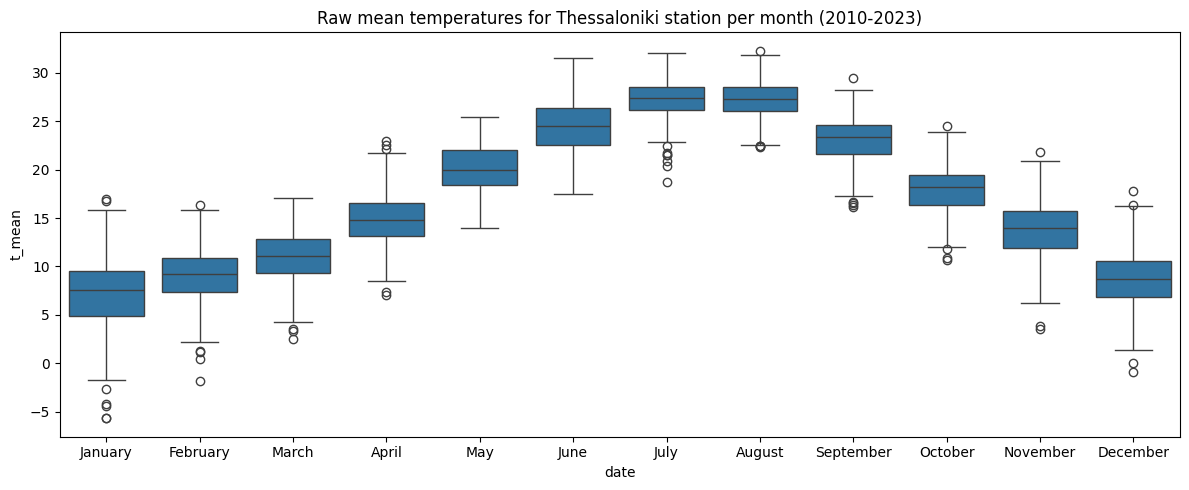

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(x=thessaloniki_clean.date.dt.month_name(), y = thessaloniki_clean.t_mean)
plt.title("Raw mean temperatures for Thessaloniki station per month (2010-2023)")
plt.tight_layout()
plt.show()

In [ ]:
thessaloniki_clean[numeric_cols]

,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,wg
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5108,11.4,16.6,7.9,81.199997,94.0,67.0,1022.700012,1027.000000,1019.400024,0.0,6.8,27.4
5109,10.0,14.6,6.7,85.199997,90.0,75.0,1026.400024,1028.900024,1023.500000,0.0,1.8,8.0
5110,9.0,12.9,6.3,90.400002,95.0,78.0,1021.299988,1023.500000,1019.700012,0.4,2.0,12.9
5111,8.4,12.4,5.6,90.300003,96.0,76.0,1019.799988,1021.400024,1018.700012,0.2,2.0,11.3


In [ ]:
all_null_rows = thessaloniki_clean[thessaloniki_clean[["t_mean","t_max","t_min"]].isna().all(axis=1)]
all_null_rows

,date,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,dwd,wg,station
0,2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thessaloniki
1,2010-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thessaloniki
2,2010-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thessaloniki
3,2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thessaloniki
4,2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thessaloniki
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4227,2021-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3,S,12.900000,thessaloniki
4236,2021-08-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thessaloniki
4237,2021-08-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thessaloniki
4238,2021-08-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,thessaloniki


In [ ]:
all_null_rows.loc[:, ['year']] = all_null_rows.date.dt.year
all_null_rows['year'].value_counts(dropna=False, normalize=False)


,count
year,
2010,365
2011,365
2012,55
2021,7
2014,2
2015,2


In [ ]:
all_null_rows.loc[:, ['month']] = all_null_rows.date.dt.month_name()
all_null_rows[all_null_rows.year == 2012]['month'].value_counts(dropna=False, normalize=False)

,count
month,
January,31
February,22
June,1
December,1


There are rows for every day of the year

In [ ]:
thessaloniki_clean.loc[:, ['year']] = thessaloniki_clean.date.dt.year

In [ ]:
thessaloniki_clean.year.value_counts(dropna=False, normalize = False).sort_index()

,count
year,
2010,365
2011,365
2012,366
2013,365
2014,365
2015,365
2016,366
2017,365
2018,365


### Load All

In [11]:
stations = pd.read_csv('/content/stations_data/meteo_data/stations_list.csv', header = 0, index_col=None)
station_names = stations['stations'].unique()
station_names

array(['aghiosnikolaos', 'alexandroupolis', 'amfiklia', 'argos', 'arta',
       'athens', 'chania', 'dion', 'drama', 'florina', 'grevena',
       'heraclion', 'igoumenitsa', 'ioannina', 'ithaki', 'kea', 'kerkyra',
       'kilkis', 'kyparissia', 'larissa', 'lavrio', 'lefkada', 'lemnos',
       'livadeia', 'megalopoli', 'petrokefali', 'mornos1', 'naousa',
       'nemea', 'nevrokopi', 'notiopedio', 'orestiada', 'paros', 'patra',
       'pirgos', 'polygyros', 'ptolemaida', 'rethymno', 'samos',
       'samothraki', 'skopelos', 'sparti', 'tanagra', 'thessaloniki',
       'tinos', 'trikala', 'tripoli', 'vatopedi', 'veroia', 'volos',
       'xanthi', 'lindos', 'gavalou', 'karpenisitown'], dtype=object)

In [12]:
def load_data() -> pd.DataFrame:
  stations=pd.read_csv('/content/stations_data/meteo_data/stations_list.csv', header=0, index_col=None)
  station_names=stations['stations'].unique()
  dfs = []
  for name in station_names:
    station_df = pd.read_csv(f'/content/stations_data/meteo_data/stations_data/{name}.csv', header = 0, index_col=None)
    # add identifier for the source
    station_df.loc[:, 'station'] = name
    # helper for column names
    station_df.columns = pd.Index([colname.replace(" ", "_").lower() for colname in station_df.columns])
    dfs.append(station_df)

  # return new DataFrame with index = (0,...,n)
  return pd.concat(dfs, axis = 0, ignore_index = True)

In [13]:
df = load_data()
df.head()

,date,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,dwd,wg,station
0,2010-01-01,21.7,27.4,17.4,43.6,78,20,1008.3,1010.4,1005.4,0.0,15.6,SE,72.4,aghiosnikolaos
1,2010-01-02,17.5,20.8,14.1,58.6,82,37,1009.4,1012.0,1007.5,0.0,7.7,W,48.3,aghiosnikolaos
2,2010-01-03,16.5,19.1,14.3,54.4,68,38,1012.8,1015.0,1011.3,0.0,8.5,WNW,45.1,aghiosnikolaos
3,2010-01-04,14.0,15.9,11.9,62.5,70,53,1018.9,1021.5,1014.6,0.0,13.9,N,57.9,aghiosnikolaos
4,2010-01-05,14.4,16.8,11.7,70.2,79,63,1019.2,1021.5,1016.4,0.0,13.1,S,62.8,aghiosnikolaos


In [14]:
df.shape, df.index.nunique()

((276102, 15), 276102)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276102 entries, 0 to 276101
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   date      276102 non-null  object
 1   t_mean    276102 non-null  object
 2   t_max     276102 non-null  object
 3   t_min     276102 non-null  object
 4   rh_mean   276102 non-null  object
 5   rh_max    276102 non-null  object
 6   rh_min    276102 non-null  object
 7   prs_mean  276102 non-null  object
 8   prs_max   276102 non-null  object
 9   prs_min   276102 non-null  object
 10  ac_r      276102 non-null  object
 11  ws_mean   276102 non-null  object
 12  dwd       276102 non-null  object
 13  wg        276102 non-null  object
 14  station   276102 non-null  object
dtypes: object(15)
memory usage: 31.6+ MB


In [16]:
df[df.station == 'thessaloniki']

,date,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,dwd,wg,station
219859,2010-01-01,---,---,---,---,---,---,---,---,---,---,---,---,---,thessaloniki
219860,2010-01-02,---,---,---,---,---,---,---,---,---,---,---,---,---,thessaloniki
219861,2010-01-03,---,---,---,---,---,---,---,---,---,---,---,---,---,thessaloniki
219862,2010-01-04,---,---,---,---,---,---,---,---,---,---,---,---,---,thessaloniki
219863,2010-01-05,---,---,---,---,---,---,---,---,---,---,---,---,---,thessaloniki
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224967,2023-12-27,11.4,16.6,7.9,81.2,94,67,1022.7,1027.0,1019.4,0.0,6.8,W,27.4,thessaloniki
224968,2023-12-28,10.0,14.6,6.7,85.2,90,75,1026.4,1028.9,1023.5,0.0,1.8,SSW,8.0,thessaloniki
224969,2023-12-29,9.0,12.9,6.3,90.4,95,78,1021.3,1023.5,1019.7,0.4,2.0,E,12.9,thessaloniki
224970,2023-12-30,8.4,12.4,5.6,90.3,96,76,1019.8,1021.4,1018.7,0.2,2.0,ESE,11.3,thessaloniki


In [17]:
def encode_data(df: pd.DataFrame) -> pd.DataFrame:
    # Define column groups
    numeric_cols = ["t_mean", "t_max", "t_min", "rh_mean", "rh_max", "rh_min", "prs_mean", "prs_max", "prs_min", "ac_r", "ws_mean", "wg"]
    categorical_cols = ["dwd", "station"]

    # replace '---' with NaN for the entire DataFrame in one go
    df = df.replace('---', np.nan)

    # convert numeric columns and raise error for value that can't be coerced
    for col in numeric_cols:
      if col in df:
        df[col] = pd.to_numeric(df[col], errors='raise').astype(np.float32)

    # convert categorical columns
    for col in categorical_cols:
      if col in df:
        df[col] = df[col].astype('category')

    # convert to date format
    df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")
    # also add the year as helper
    df.loc[:, ['year']] = df.date.dt.year

    # return sorted by station, date
    return df.sort_values(by=['station', 'date'])

In [ ]:
data = encode_data(df.copy())
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 276102 entries, 0 to 260762
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   date      276102 non-null  datetime64[ns]
 1   t_mean    265261 non-null  float32       
 2   t_max     265261 non-null  float32       
 3   t_min     265261 non-null  float32       
 4   rh_mean   265532 non-null  float32       
 5   rh_max    265532 non-null  float32       
 6   rh_min    265532 non-null  float32       
 7   prs_mean  265097 non-null  float32       
 8   prs_max   265097 non-null  float32       
 9   prs_min   265097 non-null  float32       
 10  ac_r      266023 non-null  float32       
 11  ws_mean   266242 non-null  float32       
 12  dwd       264868 non-null  category      
 13  wg        266245 non-null  float32       
 14  station   276102 non-null  category      
 15  year      276102 non-null  int32         
dtypes: category(2), datetime64[ns](1), float32(

In [18]:
data.duplicated().sum()

NameError: name 'data' is not defined

In [ ]:
data.tail()

,date,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,dwd,wg,station,year
260758,2023-12-27,10.4,18.200001,4.9,63.299999,73.0,44.0,1022.700012,1027.400024,1019.000000,0.2,1.4,NNW,11.300000,xanthi,2023
260759,2023-12-28,9.1,15.900000,4.0,63.200001,72.0,49.0,1026.800049,1029.199951,1023.500000,0.2,1.7,SE,16.100000,xanthi,2023
260760,2023-12-29,8.4,15.300000,2.9,66.599998,72.0,55.0,1021.700012,1023.599976,1019.900024,0.2,1.9,NW,16.100000,xanthi,2023
260761,2023-12-30,8.8,15.700000,3.6,65.699997,73.0,54.0,1019.900024,1021.200012,1018.599976,0.2,2.1,WNW,17.700001,xanthi,2023
260762,2023-12-31,9.7,15.300000,4.5,66.199997,71.0,56.0,1019.799988,1021.700012,1018.599976,0.2,1.3,N,9.700000,xanthi,2023


In [ ]:
grouped = data.groupby(['year','station'], observed=False).agg({'station': 'count'})
grouped.columns = ["count"]
grouped.reset_index(level=1)

,station,count
year,,
2010,aghiosnikolaos,365
2010,alexandroupolis,365
2010,amfiklia,365
2010,argos,365
2010,arta,365
...,...,...
2023,tripoli,365
2023,vatopedi,365
2023,veroia,365


every day of a year has a entry

In [ ]:
grouped[grouped['count']  < 365]

,,count
year,station,


In [ ]:
years_by_station = data.groupby('station', observed = False).agg({'year': 'unique'})
years_by_station.year.transform(len)

all stations have rows for the same number of years

In [ ]:
years_by_station.year.map(lambda x: ','.join([str(i) for i in x])).unique()

array(['2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023'],
      dtype=object)

## Clean

In [ ]:
columns_of_interest = ['date', 't_mean',  't_max',  't_min', 'station', 'year']

In [ ]:
df_sub = data[columns_of_interest]
df_sub

,date,t_mean,t_max,t_min,station,year
0,2010-01-01,21.700001,27.400000,17.4,aghiosnikolaos,2010
1,2010-01-02,17.500000,20.799999,14.1,aghiosnikolaos,2010
2,2010-01-03,16.500000,19.100000,14.3,aghiosnikolaos,2010
3,2010-01-04,14.000000,15.900000,11.9,aghiosnikolaos,2010
4,2010-01-05,14.400000,16.799999,11.7,aghiosnikolaos,2010
...,...,...,...,...,...,...
260758,2023-12-27,10.400000,18.200001,4.9,xanthi,2023
260759,2023-12-28,9.100000,15.900000,4.0,xanthi,2023
260760,2023-12-29,8.400000,15.300000,2.9,xanthi,2023
260761,2023-12-30,8.800000,15.700000,3.6,xanthi,2023


In [ ]:
df_sub.isna().sum()

,0
date,0
t_mean,10841
t_max,10841
t_min,10841
station,0
year,0


In [ ]:
def get_all_null_rows(df: pd.DataFrame, drop_subset: list[str] = ['date','year','station']) -> pd.DataFrame:
  if len(drop_subset) > 0:
    d = df.drop(columns=drop_subset)
  else:
    d = df.copy()
  return d[d.isna().all(axis = 1)] # d[d.isna().sum(axis=1)==len(d.columns)]

In [ ]:
all_null_rows = get_all_null_rows(df_sub)
all_null_rows

,t_mean,t_max,t_min
327,NaN,NaN,NaN
328,NaN,NaN,NaN
329,NaN,NaN,NaN
330,NaN,NaN,NaN
331,NaN,NaN,NaN
...,...,...,...
259059,NaN,NaN,NaN
259060,NaN,NaN,NaN
259064,NaN,NaN,NaN
259991,NaN,NaN,NaN


In [ ]:
all_null_rows.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       1631, 1930, 2063, 4224, 4225, 4227, 4236, 4237, 4238, 4239],
      dtype='int64', length=796)

In [ ]:
def get_all_null_rows_with_identifiers(df: pd.DataFrame) -> pd.DataFrame:
  all_null_rows = get_all_null_rows(df)
  # add the identifiers (station, year) to the all nulls frame and group by them
  all_null_rows_with_identifiers = pd.merge(all_null_rows, df[['station','year']], left_index=True, right_index=True).groupby(['station','year'], observed = False).station.count()
  all_null_rows_with_identifiers.name = 'counts'
  # covert the long format to wide format
  all_null_rows_with_identifiers = all_null_rows_with_identifiers.reset_index(level=0)
  return all_null_rows_with_identifiers.pivot(columns='station', values='counts')

all_null_rows_wide = get_all_null_rows_with_identifiers(df_sub)
all_null_rows_wide

station,aghiosnikolaos,alexandroupolis,amfiklia,argos,arta,athens,chania,dion,drama,florina,...,sparti,tanagra,thessaloniki,tinos,trikala,tripoli,vatopedi,veroia,volos,xanthi
year,,,,,,,,,,,,,,,,,,,,,
2010,7,0,1,365,31,0,1,9,12,0,...,1,0,365,0,0,31,4,31,6,0
2011,3,5,2,365,0,1,1,5,0,0,...,0,0,365,3,0,0,0,0,0,0
2012,0,0,2,234,0,0,4,0,2,6,...,16,0,55,3,17,0,0,0,0,4
2013,0,0,6,0,0,1,29,0,0,0,...,0,4,0,0,0,4,0,9,0,10
2014,0,0,3,0,0,0,11,7,9,10,...,11,0,2,0,0,0,12,0,1,17
2015,0,0,1,0,0,1,7,15,2,0,...,0,0,2,29,0,0,0,0,0,0
2016,0,0,4,0,0,0,2,2,0,0,...,0,13,0,2,0,0,122,3,0,0
2017,2,0,16,0,0,0,6,1,10,0,...,1,3,0,7,0,0,0,3,4,0
2018,11,6,0,0,125,0,0,3,0,0,...,0,0,0,4,0,0,24,18,0,1


In [ ]:
all_null_rows_wide["kyparissia"]

,kyparissia
year,
2010,365
2011,365
2012,314
2013,3
2014,0
2015,0
2016,1
2017,0
2018,0


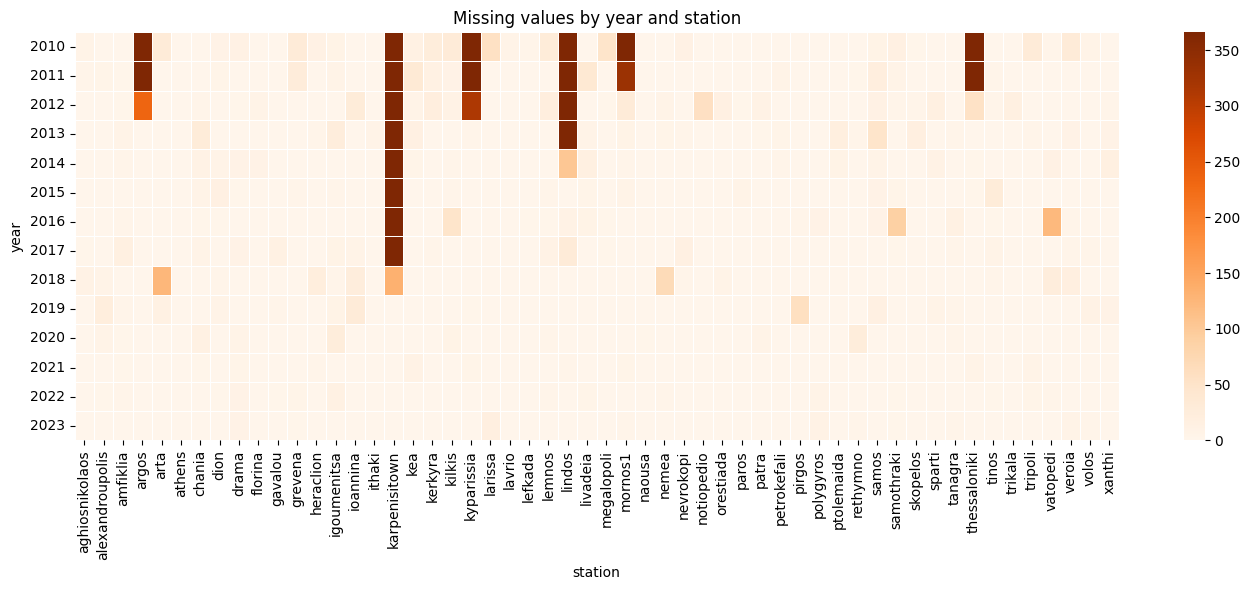

In [ ]:
plt.figure(figsize=(14,6))
plt.title('Missing values by year and station')
# plt.grid(axis='x')
sns.heatmap(all_null_rows_wide, cmap="Oranges",linewidth=.5)
plt.tight_layout()
plt.show()

##### drop all-null rows

we can't use bfill/ffill when all the values for a year are missing. So drop all the rows that belong to a year where all the values for a station are missing

In [ ]:
all_null_filtering_condition = all_null_rows_wide.isin([365,366])
all_null_filtering_condition

station,aghiosnikolaos,alexandroupolis,amfiklia,argos,arta,athens,chania,dion,drama,florina,...,sparti,tanagra,thessaloniki,tinos,trikala,tripoli,vatopedi,veroia,volos,xanthi
year,,,,,,,,,,,,,,,,,,,,,
2010,False,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2011,False,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2012,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2013,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2014,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2015,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2016,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2017,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2018,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


passing the true/false stacked values as filtering condition

In [ ]:
s1 = all_null_filtering_condition.stack()
s1[s1]

year  station      
2010  argos            True
      karpenisitown    True
      kyparissia       True
      lindos           True
      mornos1          True
      thessaloniki     True
2011  argos            True
      karpenisitown    True
      kyparissia       True
      lindos           True
      thessaloniki     True
2012  karpenisitown    True
      lindos           True
2013  karpenisitown    True
      lindos           True
2014  karpenisitown    True
2015  karpenisitown    True
2016  karpenisitown    True
2017  karpenisitown    True
dtype: bool

In [ ]:
def get_year_station_pairs_with_all_null_rows(df: pd.DataFrame) -> list[tuple[int,str]]:
  """
    Return (year, station) pairs will all null values in the rumerical columns
   """
  all_null_rows_wide = get_all_null_rows_with_identifiers(df)
  all_null_filtering_condition = all_null_rows_wide.isin([365,366])

  # Stack the wide dataframe to get a long-form Series of booleans
  # Then filter for True values and reset the index to see the pairs
  missing_years_stations = all_null_filtering_condition.stack()

  # get the multiIndex values = (year, station)
  return missing_years_stations[missing_years_stations].index.to_list()


missing_years_by_station = get_year_station_pairs_with_all_null_rows(df_sub)


print("Year-Station pairs where all rows corresponding to a specific year are null:")
for year, station in missing_years_by_station:
  print(f"Year: {year}, Station: {station}")

Year-Station pairs where all rows corresponding to a specific year are null:
Year: 2010, Station: argos
Year: 2010, Station: karpenisitown
Year: 2010, Station: kyparissia
Year: 2010, Station: lindos
Year: 2010, Station: mornos1
Year: 2010, Station: thessaloniki
Year: 2011, Station: argos
Year: 2011, Station: karpenisitown
Year: 2011, Station: kyparissia
Year: 2011, Station: lindos
Year: 2011, Station: thessaloniki
Year: 2012, Station: karpenisitown
Year: 2012, Station: lindos
Year: 2013, Station: karpenisitown
Year: 2013, Station: lindos
Year: 2014, Station: karpenisitown
Year: 2015, Station: karpenisitown
Year: 2016, Station: karpenisitown
Year: 2017, Station: karpenisitown


In [ ]:
def handle_missing_years_stations(df: pd.DataFrame) -> pd.DataFrame:

  missing_years_by_station: list[tuple[int,str]] = get_year_station_pairs_with_all_null_rows(df)

  # Create a filter for rows to exclude based on the list of (year, station) tuples
  # use apply with axis 1 (takes in each row) because we want to have access to 2 column names for each row
  mask = df.apply(lambda row: (row['year'], row['station']) in missing_years_by_station, axis=1)

  print(f"Removed rows: {mask.sum()}")

  # Create the cleaned dataframe
  data_cleaned =  df[~mask].copy()

  return data_cleaned

data_cleaned = handle_missing_years_stations(df_sub)


print(f"Original rows: {len(data)}")
print(f"Cleaned rows: {len(data_cleaned)}")
data_cleaned.head()

Removed rows: 6938
Original rows: 276102
Cleaned rows: 269164


,date,t_mean,t_max,t_min,station,year
0,2010-01-01,21.700001,27.400000,17.4,aghiosnikolaos,2010
1,2010-01-02,17.500000,20.799999,14.1,aghiosnikolaos,2010
2,2010-01-03,16.500000,19.100000,14.3,aghiosnikolaos,2010
3,2010-01-04,14.000000,15.900000,11.9,aghiosnikolaos,2010
4,2010-01-05,14.400000,16.799999,11.7,aghiosnikolaos,2010


In [ ]:
data_cleaned.isna().sum()

,0
date,0
t_mean,3903
t_max,3903
t_min,3903
station,0
year,0


## Step 1: choosing the reference locations

In [ ]:
stations

In [ ]:
data_cleaned.shape

(269164, 6)

In [ ]:
data_cleaned

,date,t_mean,t_max,t_min,station,year
0,2010-01-01,21.700001,27.400000,17.4,aghiosnikolaos,2010
1,2010-01-02,17.500000,20.799999,14.1,aghiosnikolaos,2010
2,2010-01-03,16.500000,19.100000,14.3,aghiosnikolaos,2010
3,2010-01-04,14.000000,15.900000,11.9,aghiosnikolaos,2010
4,2010-01-05,14.400000,16.799999,11.7,aghiosnikolaos,2010
...,...,...,...,...,...,...
260758,2023-12-27,10.400000,18.200001,4.9,xanthi,2023
260759,2023-12-28,9.100000,15.900000,4.0,xanthi,2023
260760,2023-12-29,8.400000,15.300000,2.9,xanthi,2023
260761,2023-12-30,8.800000,15.700000,3.6,xanthi,2023


In [ ]:
data_cleaned.isna().sum()

,0
date,0
t_mean,3903
t_max,3903
t_min,3903
station,0
year,0


### Choose only stations with complete data for years 2012 to 2023

Data for karpenisitown is only available after 2018 and for Lindos after 2014. Better to drop these 2 stations and continue with data from 2012 to 2023 from all other stations

In [ ]:
stations_mask = data_cleaned.station.isin(['karpenisitown', 'lindos'])
data_final = data_cleaned.copy()[~stations_mask]
# we must also remove the categories from the dtype of the column
data_final.station = data_final.station.astype(pd.CategoricalDtype(categories = data_final.station.cat.remove_categories(['karpenisitown', 'lindos']).unique()))
years_mask = data_final.year < 2012
data_final = data_final[~years_mask]

In [ ]:
data_final.groupby('station', observed=False).year.unique().transform(len)

In [ ]:
data_final.shape

(227916, 6)

In [ ]:
data_final.isna().sum()

,0
date,0
t_mean,2653
t_max,2653
t_min,2653
station,0
year,0


#### bfil,ffil and dropna

In [ ]:
m1 = data_final[data_final.t_mean.isna()]
m2 = m1[['station', 'year']].value_counts(dropna=False, normalize=False)
m3 = m2.reset_index(level=0).pivot(columns='station', values='count').dropna(how='all', axis=1)
# m3.fillna(0, inplace=True)
m3

station,kyparissia,argos,arta,vatopedi,samothraki,nemea,pirgos,notiopedio,thessaloniki,samos,...,florina,ithaki,tripoli,paros,petrokefali,grevena,lefkada,naousa,megalopoli,athens
year,,,,,,,,,,,,,,,,,,,,,
2012,314.0,234.0,NaN,NaN,4.0,7.0,NaN,58.0,55.0,12.0,...,6.0,NaN,NaN,2.0,NaN,NaN,1.0,NaN,2.0,NaN
2013,3.0,NaN,NaN,NaN,NaN,5.0,NaN,1.0,NaN,50.0,...,NaN,7.0,4.0,NaN,5.0,NaN,NaN,1.0,NaN,1.0
2014,NaN,NaN,NaN,12.0,NaN,NaN,1.0,NaN,2.0,7.0,...,10.0,NaN,NaN,NaN,4.0,NaN,1.0,NaN,NaN,NaN
2015,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,2.0,10.0,...,NaN,NaN,NaN,6.0,NaN,3.0,NaN,NaN,NaN,1.0
2016,1.0,NaN,NaN,122.0,90.0,NaN,3.0,NaN,NaN,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,NaN
2017,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,2.0,NaN
2018,NaN,NaN,125.0,24.0,NaN,69.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,1.0,NaN,1.0,NaN,NaN
2019,2.0,NaN,14.0,NaN,NaN,1.0,59.0,NaN,NaN,15.0,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN
2020,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,2.0,NaN,NaN


In [ ]:
m3.sum(axis=1).sum() == 2653

np.True_

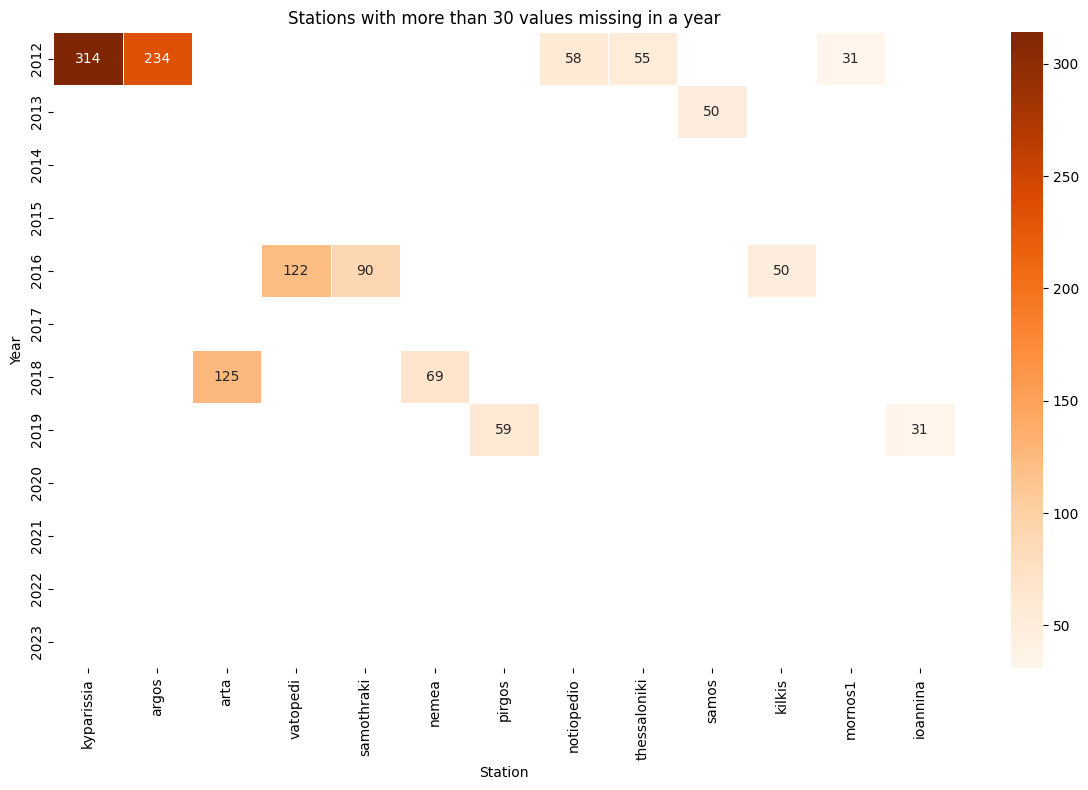

In [ ]:
plt.figure(figsize=(12,8))
plt.title('Stations with more than 30 values missing in a year')
sns.heatmap(m3[m3>30].dropna(how='all', axis=1), cmap="Oranges",linewidth=.5, annot=True, fmt='g')
plt.xlabel('Station')
plt.ylabel('Year')
plt.tight_layout()
# plt.grid(axis='x')
plt.show()

In [ ]:
def fill_drop_missing_values(df: pd.DataFrame) -> pd.DataFrame:
  # # fill forwards and backwards for up to 3 days
  df = df.bfill(limit=3)
  df = df.ffill(limit=3)
  # # drop other N/A that we don't want to fill
  df = df.dropna()
  return df

data_final = fill_drop_missing_values(data_final.copy())


In [ ]:
data_final.isna().sum()

,0
date,0
t_mean,0
t_max,0
t_min,0
station,0
year,0


In [ ]:
data_final.shape

(226416, 6)

In [ ]:
display(data_final.apply(lambda x: x.unique()))

,0
date,"[2012-01-01 00:00:00, 2012-01-02 00:00:00, 201..."
t_mean,"[11.6, 11.3, 10.8, 11.7, 14.4, 11.8, 12.0, 12...."
t_max,"[13.3, 12.8, 13.9, 13.8, 14.7, 16.9, 13.6, 14...."
t_min,"[10.1, 8.7, 8.3, 7.4, 9.2, 10.2, 10.3, 9.8, 9...."
station,"['aghiosnikolaos', 'alexandroupolis', 'amfikli..."
year,"[2012, 2013, 2014, 2015, 2016, 2017, 2018, 201..."


## Save to and load from final csv

In [ ]:
data_final.to_csv('/content/data_final.csv')

In [ ]:
!head -n 10 /content/data_final.csv

,date,t_mean,t_max,t_min,station,year
730,2012-01-01,11.6,13.3,10.1,aghiosnikolaos,2012
731,2012-01-02,11.3,12.8,8.7,aghiosnikolaos,2012
732,2012-01-03,10.8,13.9,8.3,aghiosnikolaos,2012
733,2012-01-04,10.8,13.8,7.4,aghiosnikolaos,2012
734,2012-01-05,11.7,14.7,9.2,aghiosnikolaos,2012
735,2012-01-06,14.4,16.9,10.2,aghiosnikolaos,2012
736,2012-01-07,11.8,13.6,10.3,aghiosnikolaos,2012
737,2012-01-08,12.0,14.3,9.8,aghiosnikolaos,2012
738,2012-01-09,12.3,15.6,9.1,aghiosnikolaos,2012


#### Code for reading from saved csv

In [26]:
data_final = pd.read_csv('/content/data_final.csv', index_col=0, header = 0,  engine="pyarrow", dtype_backend="pyarrow")

In [27]:
data_final = encode_data(data_final)

In [28]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 226416 entries, 730 to 260762
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   date     226416 non-null  datetime64[ns]
 1   t_mean   226416 non-null  float32       
 2   t_max    226416 non-null  float32       
 3   t_min    226416 non-null  float32       
 4   station  226416 non-null  category      
 5   year     226416 non-null  int64[pyarrow]
dtypes: category(1), datetime64[ns](1), float32(3), int64[pyarrow](1)
memory usage: 8.0 MB


## Utils

In [29]:
def get_day_for_month(df: pd.DataFrame) -> dict:
  values =  df[['yd','month']].values
  month_set = {a[0]: a[1] for a in values if not a[0] % 29}
  return month_set

In [30]:
def get_station_data(df:pd.DataFrame, station:str, reset_index=False)->pd.DataFrame:
  if reset_index:
    return df[df.station == station].reset_index(drop=True)
  return df[df.station == station]

In [31]:
def get_best_param_index(errors: np.ndarray) -> int:
  return np.argmin(errors)

## Step 2: Compute national daily series 2012-2023 and 2025 (from Open-Meteo)

In [32]:
data_final.describe(include='all')

,date,t_mean,t_max,t_min,station,year
count,226416,226416.000000,226416.000000,226416.000000,226416,226416.0
unique,NaN,NaN,NaN,NaN,52,<NA>
top,NaN,NaN,NaN,NaN,grevena,<NA>
freq,NaN,NaN,NaN,NaN,4383,<NA>
mean,2018-01-07 16:34:11.473394176,16.843576,22.011381,11.982607,NaN,2017.519592
min,2012-01-01 00:00:00,-17.600000,-11.800000,-67.800003,NaN,2012.0
25%,2015-01-10 00:00:00,11.400000,15.900000,6.900000,NaN,2015.0
50%,2018-01-08 00:00:00,16.700001,21.799999,12.100000,NaN,2018.0
75%,2021-01-07 00:00:00,23.100000,28.799999,17.600000,NaN,2021.0
max,2023-12-31 00:00:00,38.700001,45.900002,33.599998,NaN,2023.0


In [33]:
data_final.duplicated().sum()

np.int64(0)

### Create a reference set (2012-2023) and a most recent set for 2025 with data from Open-Meteo

Since we cannot compute the median value, we are interested only at the t_mean across the 52 locations for each day in the period from 2012 to 2023

In [34]:
national_mean_temperature_2012_2023 = data_final[['date','year', 'station','t_mean']].reset_index(drop=True)
national_mean_temperature_2012_2023

,date,year,station,t_mean
0,2012-01-01,2012,aghiosnikolaos,11.6
1,2012-01-02,2012,aghiosnikolaos,11.3
2,2012-01-03,2012,aghiosnikolaos,10.8
3,2012-01-04,2012,aghiosnikolaos,10.8
4,2012-01-05,2012,aghiosnikolaos,11.7
...,...,...,...,...
226411,2023-12-27,2023,xanthi,10.4
226412,2023-12-28,2023,xanthi,9.1
226413,2023-12-29,2023,xanthi,8.4
226414,2023-12-30,2023,xanthi,8.8


In [35]:
national_mean_temperature_2012_2023.station.unique()

['aghiosnikolaos', 'alexandroupolis', 'amfiklia', 'argos', 'arta', ..., 'tripoli', 'vatopedi', 'veroia', 'volos', 'xanthi']
Length: 52
Categories (52, string[pyarrow]): [aghiosnikolaos, alexandroupolis, amfiklia, argos, ..., vatopedi,
                                   veroia, volos, xanthi]

Compute the day of year to help with computations

In [36]:
national_mean_temperature_2012_2023.loc[:, ['yd']] = national_mean_temperature_2012_2023.date.dt.day_of_year
national_mean_temperature_2012_2023.loc[:, ['month']] = national_mean_temperature_2012_2023.date.dt.month_name()
national_mean_temperature_2012_2023

,date,year,station,t_mean,yd,month
0,2012-01-01,2012,aghiosnikolaos,11.6,1,January
1,2012-01-02,2012,aghiosnikolaos,11.3,2,January
2,2012-01-03,2012,aghiosnikolaos,10.8,3,January
3,2012-01-04,2012,aghiosnikolaos,10.8,4,January
4,2012-01-05,2012,aghiosnikolaos,11.7,5,January
...,...,...,...,...,...,...
226411,2023-12-27,2023,xanthi,10.4,361,December
226412,2023-12-28,2023,xanthi,9.1,362,December
226413,2023-12-29,2023,xanthi,8.4,363,December
226414,2023-12-30,2023,xanthi,8.8,364,December


### Get data for 2025 from Open-Meteo for each station

REF:
- https://open-meteo.com/en/docs/historical-weather-api
- https://github.com/open-meteo/python-requests/tree/main#readme

In [ ]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

In [38]:
stations_filtered = stations[stations.stations.isin(national_mean_temperature_2012_2023.station.unique())].reset_index()
stations_filtered

,index,stations,latitude,longitude,altitude
0,0,aghiosnikolaos,35.187909,25.715552,30.0
1,1,alexandroupolis,40.876310,25.858280,69.0
2,2,amfiklia,38.611420,22.640530,245.0
3,3,argos,37.628115,22.713401,38.0
4,4,arta,39.172784,20.999435,50.0
5,5,athens,37.978408,23.715448,50.0
6,6,chania,35.533365,24.068349,137.0
7,7,dion,40.223638,22.470709,50.0
8,8,drama,41.117828,24.143734,83.0
9,9,florina,40.794947,21.420556,637.0


In [39]:
latitudes_list = stations_filtered['latitude'].tolist()
longitudes_list = stations_filtered['longitude'].tolist()
station_names_list = stations_filtered['stations'].tolist()
paramsl = []

step = 2
for c in range(0, len(latitudes_list), step):
  params = {
      "latitude": latitudes_list[c:c+step],
      "longitude": longitudes_list[c:c+step],
      "start_date": "2025-01-01",
      "end_date": "2025-12-31",
      "daily": [
          "temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
          "temperature_2m_mean"
    ],
    "timezone": "Europe/Athens"
}
  paramsl.append(params)
len(paramsl)

26

In [40]:
import openmeteo_requests
import asyncio

async def get_open_meteo_data(stations: pd.DataFrame):
    openmeteo_daily_data = []
    # Use the AsyncClient
    openmeteo = openmeteo_requests.AsyncClient()

    # Use the archive API for 2025 (historical as of July 2026)
    url = f"https://archive-api.open-meteo.com/v1/archive"

    latitudes_list = stations_filtered['latitude'].tolist()
    longitudes_list = stations_filtered['longitude'].tolist()
    station_names_list = stations_filtered['stations'].tolist()

    step = 2
    for c in range(0, len(latitudes_list), step):
        params = {
            "latitude": latitudes_list[c:c+step],
            "longitude": longitudes_list[c:c+step],
            "start_date": "2025-01-01",
            "end_date": "2025-12-31",
            "daily": ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean"]
            # default timezone is gmt
        }

        responses = await openmeteo.weather_api(url, params=params)

        for i, response in enumerate(responses):

            station_name = station_names_list[c:c+step][i]
            daily = response.Daily()

            # Create a date range that matches the length of the returned data

            print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")
            print(daily.Time())
            print(daily.TimeEnd())
            print(daily.Interval())


            temp_mean = daily.Variables(2).ValuesAsNumpy()
            date_range = pd.date_range(
              start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
              end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
              freq = pd.Timedelta(seconds = daily.Interval()),
              inclusive = "left"
            )

            daily_data = {
                "date": date_range,
                "station": station_name,
                "t_mean": temp_mean,
                "t_max": daily.Variables(0).ValuesAsNumpy(),
                "t_min": daily.Variables(1).ValuesAsNumpy()
            }
            openmeteo_daily_data.append(pd.DataFrame(data=daily_data))

    return openmeteo_daily_data

In [94]:
import nest_asyncio
nest_asyncio.apply()

openmeteo_daily_data = asyncio.run(get_open_meteo_data(stations[stations.stations.isin(national_mean_temperature_2012_2023.station.unique())]))

open_meteo_daily_df = pd.concat(openmeteo_daily_data, ignore_index=True)

Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to GMT+0: 0s
1735689600
1767225600
86400
Timezone difference to G

In [95]:
print("\nDaily data from Open-Meteo for all stations (2025):\n")
display(open_meteo_daily_df.head())


Daily data from Open-Meteo for all stations (2025):



,date,station,t_mean,t_max,t_min
0,2025-01-01 00:00:00+00:00,aghiosnikolaos,12.602000,16.002001,10.002000
1,2025-01-02 00:00:00+00:00,aghiosnikolaos,12.260331,16.502001,8.052000
2,2025-01-03 00:00:00+00:00,aghiosnikolaos,14.433249,18.002001,10.901999
3,2025-01-04 00:00:00+00:00,aghiosnikolaos,14.649917,16.352001,12.952000
4,2025-01-05 00:00:00+00:00,aghiosnikolaos,13.702003,16.902000,10.252000


In [96]:
open_meteo_daily_df.isna().sum().sum()

np.int64(0)

In [97]:
open_meteo_daily_df.duplicated().sum()

np.int64(0)

#### Encode the data to be the same as our national set

In [98]:
open_meteo_daily_df=encode_data(open_meteo_daily_df)
open_meteo_daily_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18980 entries, 0 to 18614
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype              
---  ------   --------------  -----              
 0   date     18980 non-null  datetime64[ns, UTC]
 1   station  18980 non-null  category           
 2   t_mean   18980 non-null  float32            
 3   t_max    18980 non-null  float32            
 4   t_min    18980 non-null  float32            
 5   year     18980 non-null  int32              
dtypes: category(1), datetime64[ns, UTC](1), float32(3), int32(1)
memory usage: 614.1 KB


In [46]:
(open_meteo_daily_df.groupby('station', observed = False).count() < 365).sum(axis = 1).sum()

np.int64(0)

In [92]:
open_meteo_daily_df.describe(include='all')

,date,station,t_mean,t_max,t_min,year,yd,month
count,18980,18980,18980.000000,18980.000000,18980.000000,18980.0,18980.000000,18980
unique,NaN,52,NaN,NaN,NaN,NaN,NaN,12
top,NaN,aghiosnikolaos,NaN,NaN,NaN,NaN,NaN,January
freq,NaN,365,NaN,NaN,NaN,NaN,NaN,1612
mean,2025-07-02 00:00:00+00:00,NaN,17.149590,21.645634,13.057208,2025.0,183.000000,NaN
min,2025-01-01 00:00:00+00:00,NaN,-3.373084,-2.750000,-8.076000,2025.0,1.000000,NaN
25%,2025-04-02 00:00:00+00:00,NaN,11.594937,15.626000,8.050000,2025.0,92.000000,NaN
50%,2025-07-02 00:00:00+00:00,NaN,16.507710,20.654250,12.870001,2025.0,183.000000,NaN
75%,2025-10-01 00:00:00+00:00,NaN,23.806767,28.673250,18.525999,2025.0,274.000000,NaN
max,2025-12-31 00:00:00+00:00,NaN,35.953747,43.076000,31.424999,2025.0,365.000000,NaN


In [99]:
# Add year, yd, and month to the fetched data
open_meteo_daily_df['year'] = open_meteo_daily_df.date.dt.year
open_meteo_daily_df['yd'] = open_meteo_daily_df.date.dt.day_of_year
open_meteo_daily_df['month'] = open_meteo_daily_df.date.dt.month_name()

display(open_meteo_daily_df.head())

,date,station,t_mean,t_max,t_min,year,yd,month
0,2025-01-01 00:00:00+00:00,aghiosnikolaos,12.602000,16.002001,10.002000,2025,1,January
1,2025-01-02 00:00:00+00:00,aghiosnikolaos,12.260331,16.502001,8.052000,2025,2,January
2,2025-01-03 00:00:00+00:00,aghiosnikolaos,14.433249,18.002001,10.901999,2025,3,January
3,2025-01-04 00:00:00+00:00,aghiosnikolaos,14.649917,16.352001,12.952000,2025,4,January
4,2025-01-05 00:00:00+00:00,aghiosnikolaos,13.702003,16.902000,10.252000,2025,5,January


In [100]:
open_meteo_daily_df.groupby('station', observed = False).count()

,date,t_mean,t_max,t_min,year,yd,month
station,,,,,,,
aghiosnikolaos,365,365,365,365,365,365,365
alexandroupolis,365,365,365,365,365,365,365
amfiklia,365,365,365,365,365,365,365
argos,365,365,365,365,365,365,365
arta,365,365,365,365,365,365,365
athens,365,365,365,365,365,365,365
chania,365,365,365,365,365,365,365
dion,365,365,365,365,365,365,365
drama,365,365,365,365,365,365,365


we now have 52*365 = 18980 observations for 1 year (2025)

In [101]:
open_meteo_daily_df.groupby('year').count()

,date,station,t_mean,t_max,t_min,yd,month
year,,,,,,,
2025,18980,18980,18980,18980,18980,18980,18980


## Step 3: the daily climatology (2012-2023)

 Collapse the data to one median value per day of the year across the 52 stations

For each day of the year (1 to 366, to account for leap years), we take the median across the 12 years and the 52 stations as the `central reference`, and the 5th/95th percentiles as the `typical range`:



In [51]:
def create_clim(df: pd.DataFrame, years_list: list[int] = []) -> pd.DataFrame:
  if not len(years_list):
    cond = df.year.astype(bool)
  else:
    cond = df.year.isin(years_list)
  data_in_years_list = df[cond]
  clim = data_in_years_list.groupby('yd').agg({'t_mean': [lambda x : x.quantile(0.5), lambda x : x.quantile(0.05), lambda x : x.quantile(0.95)]})
  clim.columns = ['p50', 'p5', 'p95']
  return clim

In [52]:
national_clim = create_clim(national_mean_temperature_2012_2023)
national_clim

,p50,p5,p95
yd,,,
1,7.4,-2.480,13.300
2,7.7,-1.490,14.100
3,8.2,-0.090,14.200
4,8.7,0.790,14.710
5,8.4,-0.205,15.300
...,...,...,...
362,9.9,2.300,15.300
363,9.6,2.010,14.800
364,8.5,0.200,14.800


Note: by default the `groupby` values are sorted (`sort = True`).The `yd` values are of type int32 and they are sorted in ascending order

In [53]:
national_clim.isna().sum()

,0
p50,0
p5,0
p95,0


In [54]:
national_clim.index

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       357, 358, 359, 360, 361, 362, 363, 364, 365, 366],
      dtype='int32', name='yd', length=366)

In [55]:
expanded_clim = pd.merge(left=national_clim, right=national_mean_temperature_2012_2023[['yd','month']], left_index=True, right_on='yd', how='inner')
expanded_clim

,p50,p5,p95,yd,month
0,7.4,-2.48,13.30,1,January
366,7.4,-2.48,13.30,1,January
731,7.4,-2.48,13.30,1,January
1096,7.4,-2.48,13.30,1,January
1461,7.4,-2.48,13.30,1,January
...,...,...,...,...,...
219484,8.0,-1.55,15.35,366,December
220943,8.0,-1.55,15.35,366,December
222404,8.0,-1.55,15.35,366,December
223861,8.0,-1.55,15.35,366,December


In [56]:
expanded_clim.isna().sum()

,0
p50,0
p5,0
p95,0
yd,0
month,0


Now we have 366 noisy points, one per day of the year, each summarising 12 observations (years 2012-2023)

### Plot Clim

In [57]:
from matplotlib.dates import MonthLocator, DateFormatter
from datetime import datetime

In [58]:
from matplotlib import lines
def plot_clim(*clims:pd.DataFrame, col=None, title="", names=[]):
  """ clims have type:
   pd.DataFrame(index=[yd], cols=[p5,p50,p95'])
  """
  fig, ax = plt.subplots(figsize=(10, 6))

  # Convert the integer index (yd) to a dummy year (2012 is a leap year)
  # 2012-01-01 is yd=1, 2012-12-31 is yd=366
  # mdates.MonthLocator expects x-axis values to be in datetime format
  dates = [datetime(2012, 1, 1) + pd.Timedelta(days=int(yd) - 1) for yd in clims[0].index]

  colors=['tab:blue', 'tab:orange', 'tab:green']

  # if col is None:
  #   colors=['lightgray', 'gray', 'dimgray']

  # Main Plot
  for i,clim_df in enumerate(clims):
    column_to_plot = col
    if column_to_plot is None:
      column_to_plot = clim_df.columns[-1] # Dynamically get the last column name for this DataFrame

    # Generate a label for the current line
    current_label = f'{column_to_plot}'
    if len(names) > 0 and names[i]:
      current_label = names[i]

    # Plot the line for the current column

    ax.plot(dates, clim_df[column_to_plot], marker='o', markersize=4, label=current_label, color=colors[i])

  # Configure primary x-axis (Months)
  # Set limits to cover the full leap year exactly (using leap year 2012)
  ax.set_xlim(datetime(2012, 1, 1), datetime(2012, 12, 31, 23, 59))

  # Locate ticks at the start of each month
  ax.xaxis.set_major_locator(mdates.MonthLocator())
  # Locate minor ticks at the 15th of each month to center the labels
  ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))

  # Format major ticks (lines) but hide their labels
  ax.xaxis.set_major_formatter(plt.NullFormatter())
  # Format minor ticks (invisible) with the Month labels
  ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))

  # Remove the minor tick marks visually but keep labels
  ax.tick_params(axis='x', which='minor', length=0)

  ax.set_xlabel("Month")

  # Determine y-axis label
  ylabel_text = "Temperature (ºC)"
  if col: # If a specific column was requested, use it in the label
      ylabel_text = f"{col} {ylabel_text}"
  else: # If multiple columns were plotted (col=None case)
      ylabel_text = f"Daily Percentile {ylabel_text}"
  ax.set_ylabel(ylabel_text)

  # Create secondary x-axis (Day of Year)
  ax2 = ax.twiny()
  ax2.set_xlim(1, 366)
  # Set ticks every 30 days
  ax2.set_xticks([1,32,60,91,121,152,182,213,244,274,305,335])
  ax2.set_xlabel("Day of Year")

  plt.title(title, pad=20, fontweight='bold')
  ax.grid(True, linestyle='--', alpha=0.6)
  ax.legend() # Add legend here to show labels for each line

  plt.tight_layout()
  plt.show()

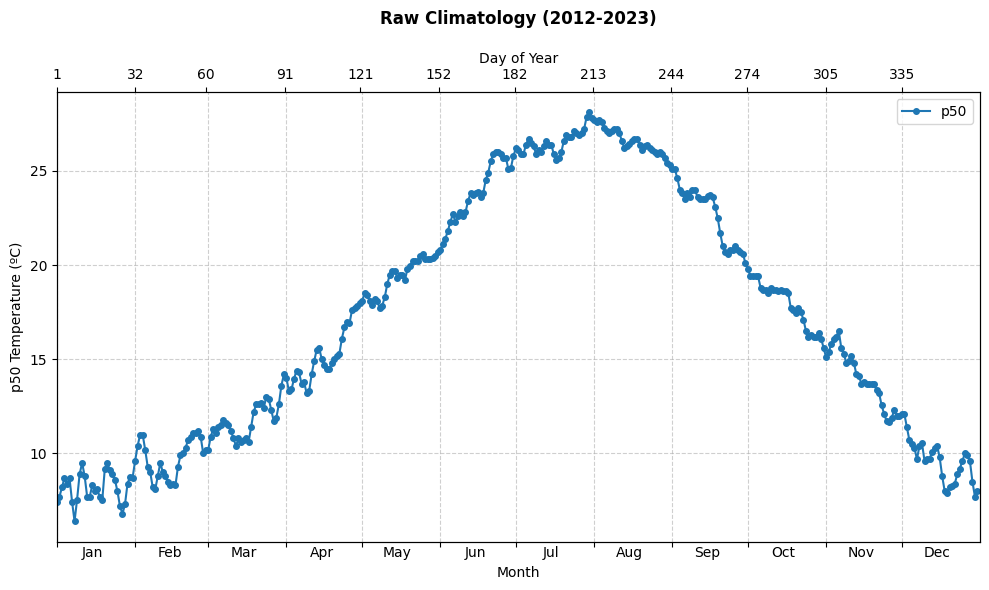

In [59]:
plot_clim(create_clim(national_mean_temperature_2012_2023), col="p50", title="Raw Climatology (2012-2023)")

Looks normal (bell shaped)

## Step 4: Smoothing

 model selection: pick a family of smoothers of increasing flexibility, and use cross-validation to find the member of that family that predicts unseen data best

In [60]:
from sklearn.model_selection import KFold

In [61]:
n_splits = 5 # number of folds for splitting years 2012-2023
K = 10 # end of the range of the K hyperparameter
period = 366
cv = KFold(n_splits=n_splits)
# we split on the years (not on the data points)
years = national_mean_temperature_2012_2023.year.unique()

print(f"each holdout fold contains {len(years)//n_splits} years out of the {len(years)}")
years

each holdout fold contains 2 years out of the 12


<ArrowExtensionArray>
[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Length: 12, dtype: int64[pyarrow]

In [62]:
from typing import Union
def rmsq(true: pd.Series, predictions: np.ndarray, axis = 1) -> Union[np.ndarray, np.float64]:
  #vectorized for axis = 1
  return np.sqrt(np.mean((predictions - true.values)**2, axis=axis) )

In [ ]:
%%bash
# cat <<EOF > /content/functions.py
# from typing import Union
# import numpy as np
# import pandas as pd

# def rmsq(true: pd.Series, predictions: np.ndarray, axis = 1) -> Union[np.ndarray, np.float64]:
#   #vectorized for axis = 1
#   return np.sqrt(np.mean((predictions - true.values)**2, axis=axis) )
# EOF

In [ ]:
# !mypy functions.py

Success: no issues found in 1 source file


#### Get CV Results function

In [63]:
from typing import Literal

In [64]:
def get_cv_results(df, cv_function:Literal['harmonic', 'loess'], K = K, period = period, fracs = None)-> tuple[np.ndarray, np.float32, int | None, np.float32 | None, int | None]:

  best_k = None,
  best_frac = None,
  best_it = None
  errors = []

  if cv_function == 'harmonic':
    # mean errors per K
    predictions, errors = harmonic_cross_val(df, K)
    overall_errors = rmsq(df.t_mean, predictions) # errors over complete predictions
  elif cv_function == 'loess':
    # mean errors per grid
    predictions, errors = loess_cross_val(df, period, fracs)
    true_values = create_clim(df, years)
    overall_errors = rmsq(true_values.p50, predictions) # errors over complete frame
  else:
   raise ValueError("cv_function must be 'harmonic' or 'loess'")

  best_param_indx = get_best_param_index(errors)

  if cv_function == 'harmonic':
    best_k = best_param_indx+1
  else:
    # best_frac,best_it=grid[best_param_indx]
    best_frac = fracs[best_param_indx]
    # best_it = int(best_it)

  lowest_error=errors[best_param_indx]

  return errors, lowest_error, best_k, best_frac, overall_errors

#### First test on some of the stations

In [65]:
stations_picks = ['thessaloniki', 'pirgos', 'athens', 'xanthi', 'nevrokopi', 'larissa','lefkada', 'heraclion', 'grevena', 'polygyros']
stations_picks

['thessaloniki',
 'pirgos',
 'athens',
 'xanthi',
 'nevrokopi',
 'larissa',
 'lefkada',
 'heraclion',
 'grevena',
 'polygyros']

#### Prepare a dataframe to store the results of the kfold processes

In [73]:
stations_results = pd.DataFrame(data = stations_picks, columns = ['station'])
stations_results

,station
0,thessaloniki
1,pirgos
2,athens
3,xanthi
4,nevrokopi
5,larissa
6,lefkada
7,heraclion
8,grevena
9,polygyros


### Harmonic Regression

In [66]:
def make_harmonic(yd:pd.Series, k_order: int, period = period) -> pd.DataFrame:
  """ transform the yd series (days of a year) into a harmonic series.
  Keyword arguments:
  yd -- the series of days in a year (pd.Series)
  k_order -- the harmonic order (e.g., 1 for 1st harmonic, 2 for 2nd)
  period -- the period of the cycle (default 366 for days in a year)
  the resulting dataframe contains cos and sin as features
  """
  dfs = []
  for k in range(1, k_order + 1):
    # vectorized
    cos = np.cos(2 * np.pi * k * yd / period)
    sin = np.sin(2 * np.pi * k * yd / period)
    # Ensure the DataFrame is created with the correct index from yd
    dfs.append(pd.DataFrame({f"cos{k}": cos, f"sin{k}": sin}, index=yd.index))
  return pd.concat(dfs, axis = 1, ignore_index = False)

first choose 1 station to test: Athens

In [75]:
athens= get_station_data(national_mean_temperature_2012_2023,'athens',True)
athens

,date,year,station,t_mean,yd,month
0,2012-01-01,2012,athens,9.4,1,January
1,2012-01-02,2012,athens,8.4,2,January
2,2012-01-03,2012,athens,8.7,3,January
3,2012-01-04,2012,athens,10.2,4,January
4,2012-01-05,2012,athens,10.5,5,January
...,...,...,...,...,...,...
4378,2023-12-27,2023,athens,13.5,361,December
4379,2023-12-28,2023,athens,12.8,362,December
4380,2023-12-29,2023,athens,12.4,363,December
4381,2023-12-30,2023,athens,12.3,364,December


In [76]:
national_mean_temperature_2012_2023.yd/period

,yd
0,0.002732
1,0.005464
2,0.008197
3,0.010929
4,0.013661
...,...
226411,0.986339
226412,0.989071
226413,0.991803
226414,0.994536


In [78]:
make_harmonic(athens.yd, K)

,cos1,sin1,cos2,sin2,cos3,sin3,cos4,sin4,cos5,sin5,cos6,sin6,cos7,sin7,cos8,sin8,cos9,sin9,cos10,sin10
0,0.999853,0.017166,0.999411,0.034328,0.998674,0.051479,0.997643,0.068615,0.996318,0.085731,0.994700,0.102821,0.992788,0.119881,0.990584,0.136906,0.988088,0.153891,0.985301,0.170830
1,0.999411,0.034328,0.997643,0.068615,0.994700,0.102821,0.990584,0.136906,0.985301,0.170830,0.978856,0.204552,0.971257,0.238033,0.962513,0.271234,0.952635,0.304115,0.941634,0.336637
2,0.998674,0.051479,0.994700,0.102821,0.988088,0.153891,0.978856,0.204552,0.967028,0.254671,0.952635,0.304115,0.935717,0.352752,0.916317,0.400454,0.894487,0.447094,0.870285,0.492548
3,0.997643,0.068615,0.990584,0.136906,0.978856,0.204552,0.962513,0.271234,0.941634,0.336637,0.916317,0.400454,0.886680,0.462383,0.852864,0.522133,0.815028,0.579421,0.773351,0.633978
4,0.996318,0.085731,0.985301,0.170830,0.967028,0.254671,0.941634,0.336637,0.909308,0.416125,0.870285,0.492548,0.824855,0.565345,0.773351,0.633978,0.716152,0.697944,0.653680,0.756771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4378,0.996318,-0.085731,0.985301,-0.170830,0.967028,-0.254671,0.941634,-0.336637,0.909308,-0.416125,0.870285,-0.492548,0.824855,-0.565345,0.773351,-0.633978,0.716152,-0.697944,0.653680,-0.756771
4379,0.997643,-0.068615,0.990584,-0.136906,0.978856,-0.204552,0.962513,-0.271234,0.941634,-0.336637,0.916317,-0.400454,0.886680,-0.462383,0.852864,-0.522133,0.815028,-0.579421,0.773351,-0.633978
4380,0.998674,-0.051479,0.994700,-0.102821,0.988088,-0.153891,0.978856,-0.204552,0.967028,-0.254671,0.952635,-0.304115,0.935717,-0.352752,0.916317,-0.400454,0.894487,-0.447094,0.870285,-0.492548
4381,0.999411,-0.034328,0.997643,-0.068615,0.994700,-0.102821,0.990584,-0.136906,0.985301,-0.170830,0.978856,-0.204552,0.971257,-0.238033,0.962513,-0.271234,0.952635,-0.304115,0.941634,-0.336637


#### Parameter Tuning using K-Fold Cross Validation


> To pick K we fit on the daily data directly (not an already-aggregated climatology), using k-fold cross-validation split **by year**, so a given year's 365/366 days stay together, fully in training or fully in test



 For each of the n_split folds, hold out that fold’s years, fit the harmonic model on the rest, predict the held-out days, and record the RMSE. In the end, we will evaluate the selected K based of the mean of RMSE of all folds

In [68]:
athens.year.unique()

<ArrowExtensionArray>
[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Length: 12, dtype: int64[pyarrow]

In [69]:
list(cv.split(years))

[(array([ 3,  4,  5,  6,  7,  8,  9, 10, 11]), array([0, 1, 2])),
 (array([ 0,  1,  2,  6,  7,  8,  9, 10, 11]), array([3, 4, 5])),
 (array([ 0,  1,  2,  3,  4,  5,  8,  9, 10, 11]), array([6, 7])),
 (array([ 0,  1,  2,  3,  4,  5,  6,  7, 10, 11]), array([8, 9])),
 (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([10, 11]))]

#### Do the whole CV loop for each candidate K

In [67]:
import statsmodels.api as sm

In [68]:
def fit_harmonic(df:pd.DataFrame, k:np.int16,  y:np.float32)-> pd.DataFrame:
  # intercept column
  X_harmonic =  pd.DataFrame(np.ones(df.shape[0]), index=df.index, columns=['const'])
  X_harmonic = X_harmonic.join(make_harmonic(df.yd, k))
  model = sm.OLS(df[y], X_harmonic)
  results = model.fit()
  harmonic_fitted = results.fittedvalues #results.predict(X_harmonic)
  df_harmonic_fitted = df.copy()
  df_harmonic_fitted.loc[:, [y]] = harmonic_fitted.astype(np.float32)
  return df_harmonic_fitted

In [69]:
def harmonic_cross_val(df: pd.DataFrame, K:int) -> tuple[np.ndarray, np.array]:
  k_oof_predictions = []
  k_oof_perf = []

  for k in range(1, K + 1):
    ## fold cache
    oof = np.zeros(df.shape[0])
    oof_errors = np.zeros(n_splits)

    for i, (train_index, test_index) in enumerate(cv.split(years)):
      train = df[df.year.isin(years[train_index])]
      test = df[df.year.isin(years[test_index])]

      X_train= pd.DataFrame(np.ones(train.shape[0]), index=train.index, columns=['const'])
      X_test = pd.DataFrame(np.ones(test.shape[0]), index=test.index, columns=['const'])

      # Build harmonic predictors: 1, 2, ..., k
      X_train = X_train.join(make_harmonic(train.yd, np.int16(k)))
      X_test = X_test.join(make_harmonic(test.yd, np.int16(k)))

      y_train = train.t_mean

      model = sm.OLS(y_train, X_train)
      results = model.fit()

      fold_predictions = results.predict(X_test)
      oof[test.index] = fold_predictions
      oof_errors[i] = rmsq(test.t_mean, np.array(fold_predictions), 0)

    print(f"Errors for K = {k}: {oof_errors}")
    k_oof_predictions.append(oof) # oof is an indexed, *complete* frame
    k_oof_perf.append(np.mean(oof_errors))
    print(f"Finished CV for K = {k}")

  return np.array(k_oof_predictions), np.array(k_oof_perf)

In [73]:
k_predictions, k_errors = harmonic_cross_val(athens, K)

Errors for K = 1: [2.49627113 2.7142269  2.37118973 2.70796164 2.66647875]
Finished CV for K = 1
Errors for K = 2: [2.46330145 2.64783589 2.34503924 2.58976966 2.67398974]
Finished CV for K = 2
Errors for K = 3: [2.45010541 2.62620917 2.33876144 2.60887737 2.63866889]
Finished CV for K = 3
Errors for K = 4: [2.45010242 2.60869814 2.32569828 2.59953996 2.64855402]
Finished CV for K = 4
Errors for K = 5: [2.44949564 2.60790325 2.33531987 2.61739146 2.66264855]
Finished CV for K = 5
Errors for K = 6: [2.4494933  2.61137103 2.33566804 2.60851073 2.65629968]
Finished CV for K = 6
Errors for K = 7: [2.44562448 2.60875942 2.33693969 2.60441939 2.70335419]
Finished CV for K = 7
Errors for K = 8: [2.44585574 2.61332235 2.34899556 2.60338926 2.72181526]
Finished CV for K = 8
Errors for K = 9: [2.4495862  2.60706918 2.38334386 2.60214141 2.72059014]
Finished CV for K = 9
Errors for K = 10: [2.45848469 2.60319848 2.38526959 2.60742092 2.73838075]
Finished CV for K = 10


In [74]:
k_predictions.shape, k_errors.shape, np.argmin(k_errors)

((10, 4383), (10,), np.int64(3))

Get results for Athens

In [75]:
errors_per_k, lowest_error, best_k, *rest = get_cv_results(athens, 'harmonic')
# print(f"estimated average performance", estimated_mean_error)
print("_____________________")
print(f"mean errors per K {errors_per_k}")
print(f"lowest error {lowest_error}")
print(f"best K is {best_k}")
print(f"overall mean errors for each K are {rest[-1]}")

Errors for K = 1: [2.49627113 2.7142269  2.37118973 2.70796164 2.66647875]
Finished CV for K = 1
Errors for K = 2: [2.46330145 2.64783589 2.34503924 2.58976966 2.67398974]
Finished CV for K = 2
Errors for K = 3: [2.45010541 2.62620917 2.33876144 2.60887737 2.63866889]
Finished CV for K = 3
Errors for K = 4: [2.45010242 2.60869814 2.32569828 2.59953996 2.64855402]
Finished CV for K = 4
Errors for K = 5: [2.44949564 2.60790325 2.33531987 2.61739146 2.66264855]
Finished CV for K = 5
Errors for K = 6: [2.4494933  2.61137103 2.33566804 2.60851073 2.65629968]
Finished CV for K = 6
Errors for K = 7: [2.44562448 2.60875942 2.33693969 2.60441939 2.70335419]
Finished CV for K = 7
Errors for K = 8: [2.44585574 2.61332235 2.34899556 2.60338926 2.72181526]
Finished CV for K = 8
Errors for K = 9: [2.4495862  2.60706918 2.38334386 2.60214141 2.72059014]
Finished CV for K = 9
Errors for K = 10: [2.45848469 2.60319848 2.38526959 2.60742092 2.73838075]
Finished CV for K = 10
_____________________
mean e

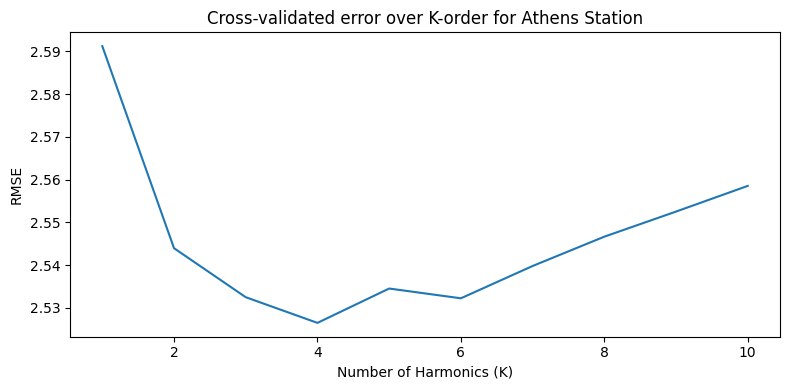

In [76]:
plt.figure(figsize=(8,4))
plt.plot(list(range(1, len(errors_per_k)+1)), errors_per_k)
plt.title("Cross-validated error over K-order for Athens Station")
plt.xlabel("Number of Harmonics (K)")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

For Athens, the error drops  from  K= 1 to K =4
 and then pick up again. That minimum, 4, is our cross-validated result for this one city.

#### Now compare best Ks for all station picks

In [77]:
stations_results.loc[:,'best_k'] = np.nan
stations_results['best_k'] = np.nan
stations_results.loc[:,'harmonic_lowest_error'] = np.nan

In [78]:
for station in stations_picks:
# for station in stations_filtered.stations.values:
  print(f"processing station {station}")
  station_data = get_station_data(national_mean_temperature_2012_2023, station, True)
  errors_per_k, lowest_error, best_K, *rest = get_cv_results(station_data, 'harmonic', K)
  row_to_update = stations_results[stations_results['station'] == station]
  stations_results.loc[row_to_update.index, 'best_k'] = best_k
  stations_results.loc[row_to_update.index, 'harmonic_lowest_error'] = lowest_error
stations_results.best_k = stations_results.best_k.astype(int)

processing station thessaloniki
Errors for K = 1: [2.38803033 2.73686014 2.3225227  2.57754874 2.57564318]
Finished CV for K = 1
Errors for K = 2: [2.34383697 2.69943521 2.37042458 2.48934488 2.58449263]
Finished CV for K = 2
Errors for K = 3: [2.33194611 2.68107221 2.36284556 2.50370447 2.57426794]
Finished CV for K = 3
Errors for K = 4: [2.31232496 2.65685148 2.33278509 2.49543625 2.58354709]
Finished CV for K = 4
Errors for K = 5: [2.31146991 2.66628353 2.32951019 2.51080703 2.60469276]
Finished CV for K = 5
Errors for K = 6: [2.30645006 2.67917972 2.33013494 2.49802813 2.59664474]
Finished CV for K = 6
Errors for K = 7: [2.31312448 2.67948878 2.34165467 2.49634737 2.60724176]
Finished CV for K = 7
Errors for K = 8: [2.30487743 2.67617014 2.35390823 2.48331376 2.62633009]
Finished CV for K = 8
Errors for K = 9: [2.31276963 2.67946656 2.38392422 2.48727612 2.62939766]
Finished CV for K = 9
Errors for K = 10: [2.32865684 2.67400524 2.38452727 2.48165802 2.66364465]
Finished CV for K =

For all stations the best K is 4. The errors range from low 2s to mid 3s

In [79]:
stations_results

,station,best_k,harmonic_lowest_error
0,thessaloniki,4,2.476189
1,pirgos,4,2.161326
2,athens,4,2.526519
3,xanthi,4,2.831213
4,nevrokopi,4,3.147449
5,larissa,4,2.731971
6,lefkada,4,2.140458
7,heraclion,4,2.337222
8,grevena,4,2.865827
9,polygyros,4,3.328481


#### Use the national data set (all the stations)

In [ ]:
# results on national level
national_errors_per_k, national_lowest_k_error, national_best_k, *national_rest = get_cv_results(national_mean_temperature_2012_2023, 'harmonic')
row_for_national = pd.DataFrame(data = ['national'], columns = ['station'])
row_for_national.loc[:, 'best_k'] = national_best_k
row_for_national.loc[:, 'harmonic_lowest_error'] = national_lowest_k_error
# concat to results df
stations_results = pd.concat([stations_results, row_for_national], ignore_index=True, axis = 0)

In [81]:
stations_results

,station,best_k,harmonic_lowest_error
0,thessaloniki,4,2.476189
1,pirgos,4,2.161326
2,athens,4,2.526519
3,xanthi,4,2.831213
4,nevrokopi,4,3.147449
5,larissa,4,2.731971
6,lefkada,4,2.140458
7,heraclion,4,2.337222
8,grevena,4,2.865827
9,polygyros,4,3.328481


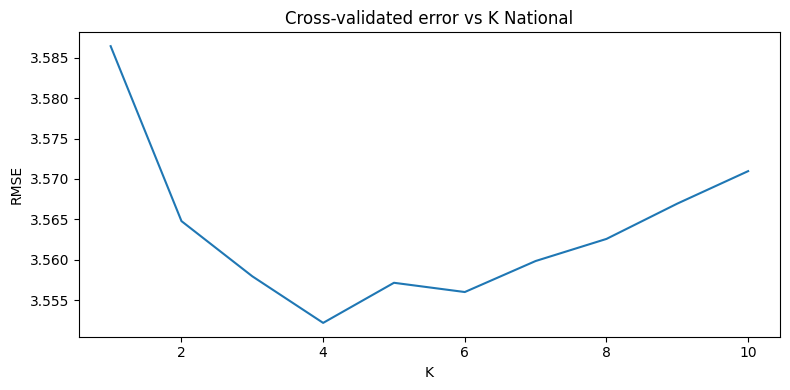

In [82]:
plt.figure(figsize=(8,4))
plt.plot(list(range(1, len(national_errors_per_k)+1)), national_errors_per_k)
plt.title("Cross-validated error vs K National")
plt.xlabel("K")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

In [83]:
stations_results[stations_results.station=="national"].best_k.item()

4

In [84]:
national_overall_errors_harnomic = national_rest[-1]
national_overall_errors_harnomic[get_best_param_index(national_overall_errors_harnomic)]

np.float64(3.5602034066100328)

#### Get the smoothed national data

In [ ]:
# harmonic_smooth_national = fit_harmonic(national_mean_temperature_2012_2023, stations_results[stations_results.station=="national"].best_k.item())
# harmonic_smooth_national

In [ ]:
# harmonic_clim = create_clim(harmonic_smooth_national)
# plot_clim(harmonic_clim, col="p50", title='Harmonic National Climatology (2012-2023)')

In [ ]:
# plot_clim(national_clim, harmonic_clim,  col="p50", title='Harmonic vs Raw Climatology (2012-2023)')

#### Compare true data with harmonic smooth data

##### Using climatology (not raw data)

In [81]:
clim = national_clim.reset_index(drop = False)
clim

,yd,p50,p5,p95
0,1,7.4,-2.480,13.300
1,2,7.7,-1.490,14.100
2,3,8.2,-0.090,14.200
3,4,8.7,0.790,14.710
4,5,8.4,-0.205,15.300
...,...,...,...,...
361,362,9.9,2.300,15.300
362,363,9.6,2.010,14.800
363,364,8.5,0.200,14.800
364,365,7.7,-1.300,14.785


In [82]:
harmonic_clim_50 = fit_harmonic(clim, int(stations_results[stations_results.station=="national"].best_k.item()), y='p50')[['yd','p50']]
harmonic_clim_50

,yd,p50
0,1,8.299623
1,2,8.258375
2,3,8.221541
3,4,8.189101
4,5,8.161022
...,...,...
361,362,8.572252
362,363,8.508905
363,364,8.449951
364,365,8.395411


In [83]:
harmonic_clim_05 = fit_harmonic(clim,int(stations_results[stations_results.station=="national"].best_k.item()), y='p5')[['yd','p5']]
harmonic_clim_05

,yd,p5
0,1,-0.710464
1,2,-0.766935
2,3,-0.816586
3,4,-0.859419
4,5,-0.895453
...,...,...
361,362,-0.326757
362,363,-0.416846
363,364,-0.500326
364,365,-0.577125


In [84]:
harmonic_clim_95 = fit_harmonic(clim, int(stations_results[stations_results.station=="national"].best_k.item()), y='p95')[['yd','p95']]
harmonic_clim_95

,yd,p95
0,1,14.986312
1,2,14.955476
2,3,14.927433
3,4,14.902117
4,5,14.879460
...,...,...
361,362,15.184181
362,363,15.138640
363,364,15.096119
364,365,15.056584


In [85]:
clim_harmonic = pd.merge(left=harmonic_clim_50, right=harmonic_clim_05, left_on='yd', right_on='yd', how='inner')
clim_harmonic = pd.merge(left=clim_harmonic, right=harmonic_clim_95, left_on='yd', right_on='yd', how='inner')
clim_harmonic.set_index('yd', inplace=True)
clim_harmonic

,p50,p5,p95
yd,,,
1,8.299623,-0.710464,14.986312
2,8.258375,-0.766935,14.955476
3,8.221541,-0.816586,14.927433
4,8.189101,-0.859419,14.902117
5,8.161022,-0.895453,14.879460
...,...,...,...
362,8.572252,-0.326757,15.184181
363,8.508905,-0.416846,15.138640
364,8.449951,-0.500326,15.096119


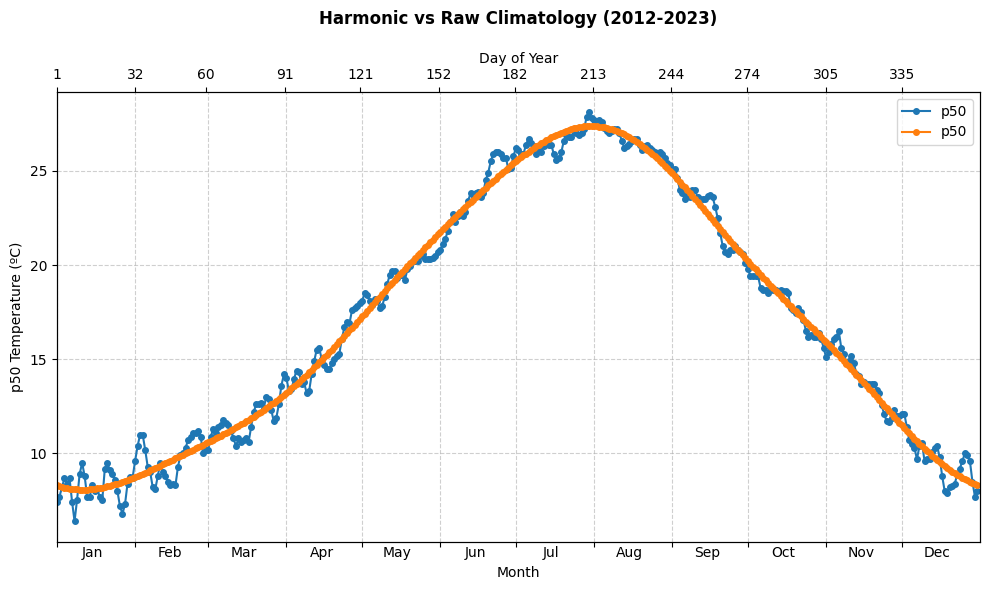

In [86]:
plot_clim(national_clim, clim_harmonic,  col="p50", title='Harmonic vs Raw Climatology (2012-2023)')

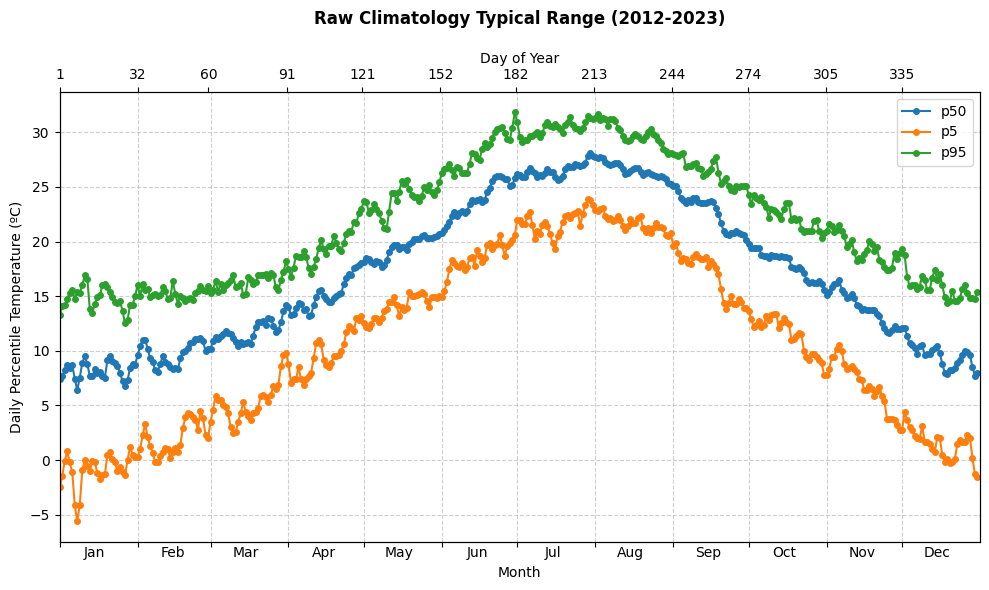

In [87]:
plot_clim(national_clim[['p50']], national_clim[['p5']], national_clim[['p95']], col=None, title='Raw Climatology Typical Range (2012-2023)')

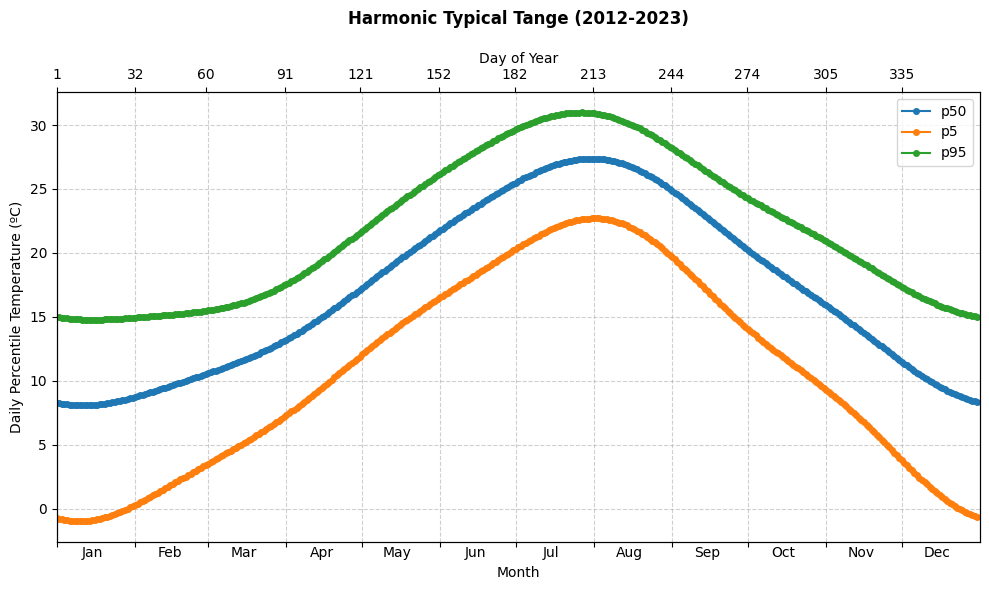

In [88]:
plot_clim(clim_harmonic[['p50']], clim_harmonic[['p5']], clim_harmonic[['p95']], col=None, title='Harmonic Typical Tange (2012-2023)')

### Local Polynomial Regression Fitting (Loess)

#### Side note: How Lowess works in Statsmodels package

In [ ]:
!curl -L -o loess.dat https://www.itl.nist.gov/div898/handbook/datasets/LOESSCMP.DAT

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1138    0  1138    0     0   2685      0 --:--:-- --:--:-- --:--:--  2690


In [ ]:
with open('/content/loess.dat', 'r') as f:
  d = f.read()
data = []
cleaned_data = []
for line in d.split('\n')[25:]:
  data.append(line.strip().split(' '))
for pair in data:
  pair = [i for i in pair if i != '']
  if(len(pair)):
    cleaned_data.append([float(i) for i in pair if i != ''])

dt = pd.DataFrame(cleaned_data, columns =['X','y'])
dt

,X,y
0,0.557820,18.63654
1,2.021727,103.49646
2,2.577325,150.35391
3,3.414029,190.51031
4,4.301408,208.70115
5,4.744839,213.71135
6,5.107378,228.49353
7,6.541166,233.55387
8,6.721618,234.55054
9,7.260058,223.89225


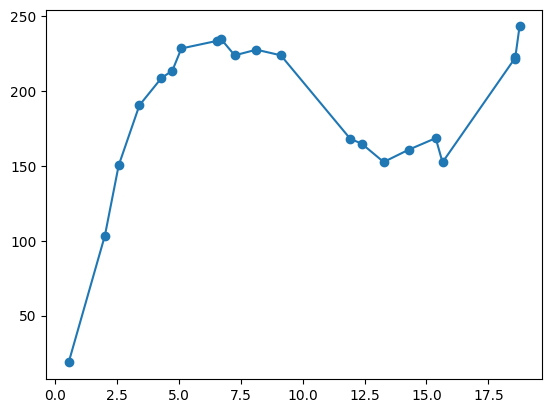

In [ ]:
plt.plot(dt.X, dt.y, marker='o')

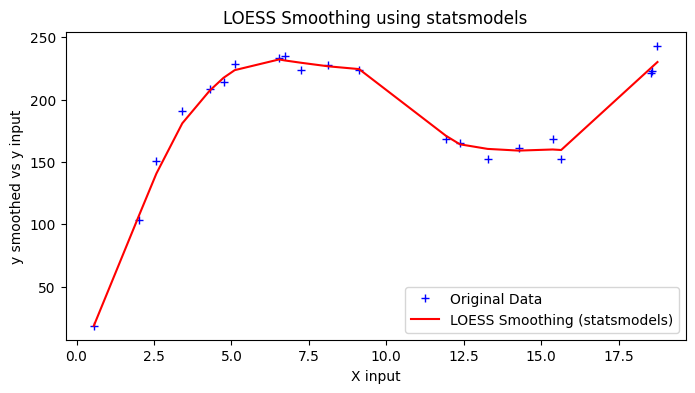

In [ ]:
import statsmodels.api as sm

# Perform LOESS smoothing using statsmodels.api.lowess
# frac parameter controls the smoothness, similar to radius in localreg
# Increase it for smoother curve, decrease for less smooth.
# it corresponds to the fraction of data points used in each local regression
loess_smoothed = sm.nonparametric.lowess(dt.y, dt.X, frac=0.3)

# The result of lowess with default `return_sorted=True` is an array where the first column is X and the second is the smoothed Y
x_smoothed, y_smoothed = loess_smoothed.T

# x_smoothed is the input dt.X and y Smoothed is the  smoothed dt.y
# print(x_smoothed == dt.X.values)

plt.figure(figsize=(8, 4))
plt.plot(dt.X, dt.y, '+', markersize=6, color='blue', label='Original Data')
plt.plot(dt.X, y_smoothed, label='LOESS Smoothing (statsmodels)', color='red')
plt.title('LOESS Smoothing using statsmodels')
plt.xlabel('X input')
plt.ylabel('y smoothed vs y input')
plt.legend()
plt.show()

#### Compute Loess for clim

We want to identify general trends for each day of the year over the compressed by day period from 2012 to 2023, so that we can see which values are actual outliers

Loess uses neighbouring data points to create multiple regressions. It works on a climatology (one summarized value per day for all the years), not raw daily data. Therefore, it needs help to “see” that day 366 and day 1 are neighbours. To fix this we glue three copies of the climatology end to end, smooth that, and keep only the middle copy

In [93]:
def fit_loess(yd: pd.Series, y: pd.Series, **params) -> pd.DataFrame:

  period = params.get('period', 366)
  frac = params.get('frac', 0.1)
  it = params.get('it', 1)
  label = params.get('label', 'p50')

  # concatenate the vectors row on row
  X = pd.concat([yd-period, yd, yd+period], ignore_index=True, axis = 0)
  y = pd.concat([y, y, y], ignore_index=True, axis = 0)

  # Note: The result of lowess with default `return_sorted=True` is an array where the first column is (the input) X and the second is the smoothed Y
  smoothed = sm.nonparametric.lowess(y.values, X.values, frac=frac, it=it, is_sorted=True)
  smoothed_df = pd.DataFrame(smoothed, columns = ['yd', label])
  smoothed_df.yd = smoothed_df.yd.astype(np.int32)

  return smoothed_df[(smoothed_df.yd > 0) & (smoothed_df.yd < 367)].reset_index(drop=True)

Note: the statsmodel lowess implementation take a second (hyper)parameter `it`. If `it > 1`, then further weighted local linear regressions are performed. This is most useful when the noise has "extremely heavy tails". Since our climatology noise is closer to t-distribution noise than Cauchy noise, will keep `it = 1`.

The `frac` parameter controls roughly how much of the data is used locally for each fitted point.

- frac=0.1 → follows the data closely, potentially noisy
- frac=0.3 → moderate smoothing
- frac=0.7 → very smooth, potentially hiding real structure

#### Example using frac=0.1

In [94]:
smoothed_01_df = fit_loess(clim.yd, clim.p50, frac=0.1)
smoothed_01_df

,yd,p50
0,1,9.229570
1,2,9.186166
2,3,9.145559
3,4,9.107805
4,5,9.072959
...,...,...
361,362,9.487159
362,363,9.430293
363,364,9.376102
364,365,9.324573


We see that `frac=0.1` doesn't follow the data very closely. Most likely we need a smaller value for `frac` so that we don't "smooth out" useful variation of the data.

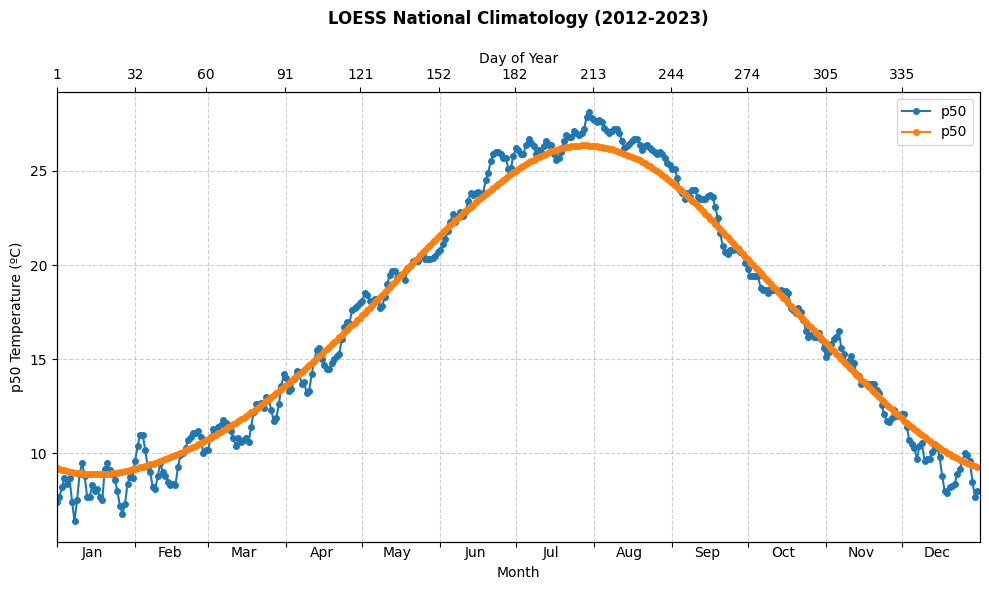

In [95]:
plot_clim(national_clim, smoothed_01_df.set_index('yd'), col="p50", title='LOESS National Climatology (2012-2023)')

#### Try multiple frac values

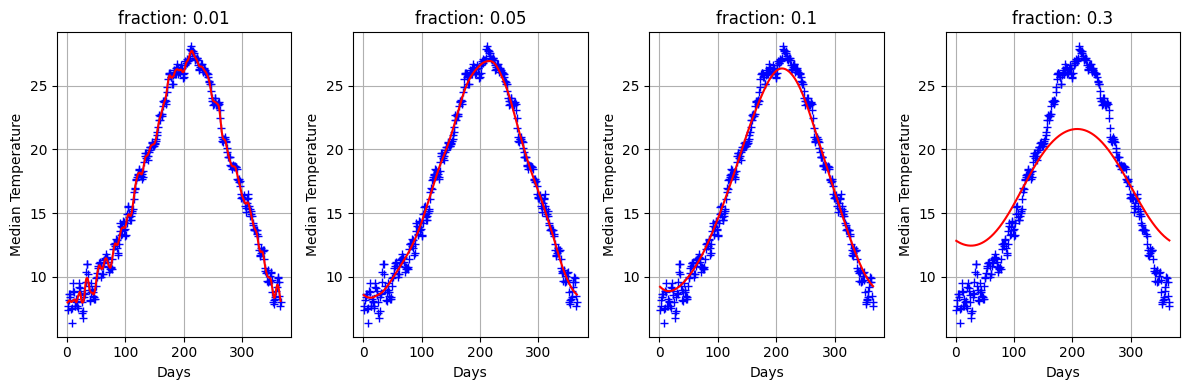

In [96]:
fraxs = [0.01,0.05, 0.1, 0.3]
smoothed = map(lambda frac: fit_loess(clim.yd, clim.p50, frac=frac), fraxs)
fig, ax = plt.subplots(1,len(fraxs), figsize=(12,4))
for i in range(len(fraxs)):
  nxt_i= next(smoothed)
  ax[i].plot(clim.yd, clim.p50, '+', markersize=6, color='blue', label='Original Data')
  ax[i].plot(nxt_i.yd,nxt_i.p50, label='LOESS Smoothing (statsmodels)', color='red')
  ax[i].set_xlabel('Days')
  ax[i].set_ylabel('Median Temperature')
  ax[i].set_title((f"fraction: {fraxs[i]}"))
  ax[i].grid(True)
plt.tight_layout()
plt.show()

Seems like 0.01 is too noisy and 0.1 is too smooth. We are going to try smoothers between this range

In [97]:
fracs = np.arange(0.0, 0.2, 0.025)
# itr = np.arange(1, 6, 1)
# grid = np.array(np.meshgrid(fracs, itr)).T.reshape(-1, 2)
# grid
fracs

array([0.   , 0.025, 0.05 , 0.075, 0.1  , 0.125, 0.15 , 0.175])

Go through the cv loop for each frac value.

In [98]:
def loess_cross_val(df, period=period, fracs=fracs) -> np.ndarray:

  loess_oof_predictions = []
  loess_oof_perf = []

  # for frac, it in grid:
  for frac in fracs:
    # fold cache
    oof = np.zeros(period)
    oof_errors = np.zeros(n_splits)

    for i, (train_idx, test_idx) in enumerate(cv.split(years)):
      train = create_clim(df, years[train_idx]).reset_index(drop=False)
      test = create_clim(df, years[test_idx]).reset_index(drop=False)
      #fit
      res = fit_loess(train['yd'], train['p50'], frac=frac, it=1)
      x = res.yd.values
      y = res.p50.values
      # loess doesn't have a 'predict' method so we
      # predict using linear interpolation (np.interp)
      predict = np.interp(test['yd'], x, y)
      oof[test.index] = predict
      oof_errors[i] = rmsq(test.p50, predict, 0) # errors for fold i

    print(f"Errors for frac = {frac}: {oof_errors}")
    loess_oof_predictions.append(oof) # oof is an indexed, *complete* frame
    loess_oof_perf.append(np.mean(oof_errors))
    print(f"Finished CV for frac = {frac}, it = 1")

  return np.array(loess_oof_predictions), np.array(loess_oof_perf)

Again, try the code just on Athens first.

In [ ]:
errors, lowest_error, _, best_frac, _ = get_cv_results(athens, 'loess', fracs = fracs)

In [100]:
errors, lowest_error

(array([1.96517826, 1.79901056, 1.78618159, 1.80096394, 1.84587319,
        1.94080507, 2.0943335 , 2.31409837]),
 np.float64(1.7861815887139947))

In [101]:
best_frac

np.float64(0.05)

#### check best loess params for stations picks

In [102]:
stations_results.loc[:,'best_frac'] = np.nan
# stations_results.loc[:,'best_it'] = np.nan
stations_results.loc[:,'loess_lowest_error'] = np.nan

In [103]:
for station in stations_picks:
  print(f"processing station {station}")
  station_data = get_station_data(national_mean_temperature_2012_2023, station, True)
  errors, lowest_error, _, best_frac, _ = get_cv_results(station_data, 'loess', fracs = fracs)
  row_to_update = stations_results[stations_results['station'] == station]
  stations_results.loc[row_to_update.index, 'best_frac'] = best_frac
  # stations_results.loc[row_to_update.index, 'best_it'] = best_it
  stations_results.loc[row_to_update.index, 'loess_lowest_error'] = lowest_error


processing station thessaloniki
Errors for frac = 0.0: [1.91140527 2.06341576 1.95807078 1.92795445 2.06703247]
Finished CV for frac = 0.0, it = 1
Errors for frac = 0.025: [1.67435214 1.94073267 1.67472849 1.78951831 1.9517287 ]
Finished CV for frac = 0.025, it = 1
Errors for frac = 0.05: [1.65278087 1.94997382 1.62031543 1.81568081 1.85143266]
Finished CV for frac = 0.05, it = 1
Errors for frac = 0.07500000000000001: [1.69509696 1.99765446 1.63707375 1.83501912 1.82124807]
Finished CV for frac = 0.07500000000000001, it = 1
Errors for frac = 0.1: [1.76129276 2.07346265 1.69465062 1.87556874 1.83209903]
Finished CV for frac = 0.1, it = 1
Errors for frac = 0.125: [1.87196722 2.1933737  1.80799108 1.95889884 1.88251564]
Finished CV for frac = 0.125, it = 1
Errors for frac = 0.15000000000000002: [2.03072175 2.36721734 1.975373   2.09538484 1.991056  ]
Finished CV for frac = 0.15000000000000002, it = 1
Errors for frac = 0.17500000000000002: [2.25565017 2.59042928 2.20633305 2.29700845 2.172

In [104]:
best_frac

np.float64(0.05)

In [105]:
stations_results

,station,best_k,harmonic_lowest_error,best_frac,loess_lowest_error
0,thessaloniki,4,2.476189,0.05,1.778037
1,pirgos,4,2.161326,0.05,1.488240
2,athens,4,2.526519,0.05,1.786182
3,xanthi,4,2.831213,0.05,2.029957
4,nevrokopi,4,3.147449,0.05,2.181745
5,larissa,4,2.731971,0.05,1.889591
6,lefkada,4,2.140458,0.05,1.470341
7,heraclion,4,2.337222,0.05,1.624932
8,grevena,4,2.865827,0.05,1.964388
9,polygyros,4,3.328481,0.05,2.405829


In [ ]:
national_loess_errors, national_lowest_loess_error, _, national_loess_best_frac, national_overall_loess_errors = get_cv_results(national_mean_temperature_2012_2023, 'loess', fracs = fracs)
row_to_update = stations_results[stations_results['station'] == 'national']
stations_results.loc[row_to_update.index, 'best_frac'] = national_loess_best_frac
# stations_results.loc[row_to_update.index, 'best_it'] = best_it
stations_results.loc[row_to_update.index, 'loess_lowest_error'] = national_lowest_loess_error

In [107]:
stations_results

,station,best_k,harmonic_lowest_error,best_frac,loess_lowest_error
0,thessaloniki,4,2.476189,0.05,1.778037
1,pirgos,4,2.161326,0.05,1.488240
2,athens,4,2.526519,0.05,1.786182
3,xanthi,4,2.831213,0.05,2.029957
4,nevrokopi,4,3.147449,0.05,2.181745
5,larissa,4,2.731971,0.05,1.889591
6,lefkada,4,2.140458,0.05,1.470341
7,heraclion,4,2.337222,0.05,1.624932
8,grevena,4,2.865827,0.05,1.964388
9,polygyros,4,3.328481,0.05,2.405829


In [108]:
national_overall_loess_errors[get_best_param_index(national_overall_loess_errors)]

np.float64(0.35808386627344774)

In [ ]:
stations_results.to_csv('/content/stations_results.csv')

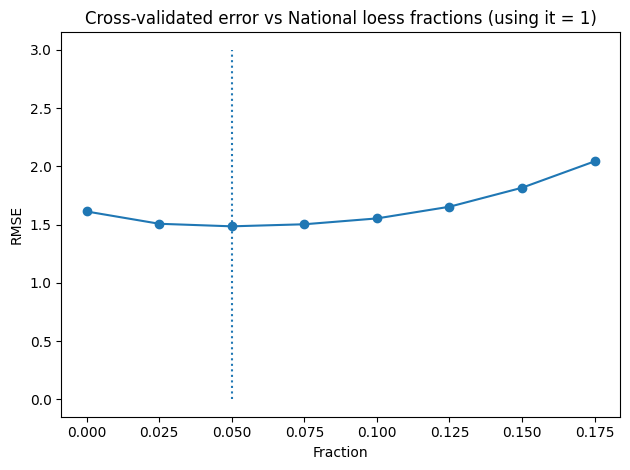

In [109]:
plt.plot(fracs,national_loess_errors, marker='o')
plt.title("Cross-validated error vs National loess fractions (using it = 1)")
plt.vlines([national_loess_best_frac], 0 , 3.0, linestyles=['dotted'])
plt.xlabel("Fraction")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

the fraction of data points used in each local regression is:

In [110]:
period*national_loess_best_frac

np.float64(18.3)

## Compare Smoothers

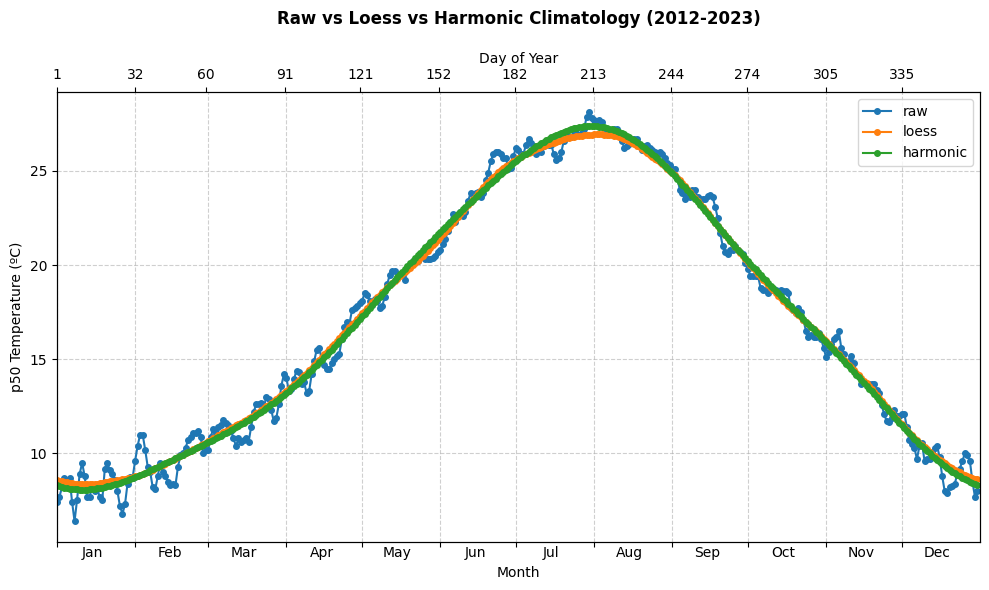

In [111]:
best_smoothed_loess = fit_loess(clim.yd, clim.p50, frac=stations_results[stations_results.station=="national"].best_frac.item())
best_smoothed_harmonic = fit_harmonic(clim,int(stations_results[stations_results.station=="national"].best_k.item()), y='p50')
plot_clim(national_clim, best_smoothed_loess.set_index('yd'), best_smoothed_harmonic.set_index('yd'),  col="p50", title='Raw vs Loess vs Harmonic Climatology (2012-2023)', names=['raw', 'loess', 'harmonic'])


##  The new chart

Since the harmonic best value `K = 4` agrees with the original article's results, lets use the harmonic smoother to create the anomaly chart

#### Create Smoothed data for central measure and range

The data driven normal is the climatology table where the median and typical range values have been fitted using the harmonic smoother.

In [89]:
clim_harmonic

,p50,p5,p95
yd,,,
1,8.299623,-0.710464,14.986312
2,8.258375,-0.766935,14.955476
3,8.221541,-0.816586,14.927433
4,8.189101,-0.859419,14.902117
5,8.161022,-0.895453,14.879460
...,...,...,...
362,8.572252,-0.326757,15.184181
363,8.508905,-0.416846,15.138640
364,8.449951,-0.500326,15.096119


In [102]:
open_meteo_daily_data = open_meteo_daily_df[national_mean_temperature_2012_2023.columns]
open_meteo_daily_data

,date,year,station,t_mean,yd,month
0,2025-01-01 00:00:00+00:00,2025,aghiosnikolaos,12.602000,1,January
1,2025-01-02 00:00:00+00:00,2025,aghiosnikolaos,12.260331,2,January
2,2025-01-03 00:00:00+00:00,2025,aghiosnikolaos,14.433249,3,January
3,2025-01-04 00:00:00+00:00,2025,aghiosnikolaos,14.649917,4,January
4,2025-01-05 00:00:00+00:00,2025,aghiosnikolaos,13.702003,5,January
...,...,...,...,...,...,...
18610,2025-12-27 00:00:00+00:00,2025,xanthi,3.756250,361,December
18611,2025-12-28 00:00:00+00:00,2025,xanthi,3.475000,362,December
18612,2025-12-29 00:00:00+00:00,2025,xanthi,2.075000,363,December
18613,2025-12-30 00:00:00+00:00,2025,xanthi,4.064583,364,December


#### Note: there is no February 29 in year 2025, so we have to fill the missing value when we merge the normal and the 2025 tables

In [103]:
national_mean_temperature_2012_2023[national_mean_temperature_2012_2023["month"].isin(["February", "March"])].groupby(["year","month"]).yd.max()

year  month   
2012  February    60
      March       91
2013  February    59
      March       90
2014  February    59
      March       90
2015  February    59
      March       90
2016  February    60
      March       91
2017  February    59
      March       90
2018  February    59
      March       90
2019  February    59
      March       90
2020  February    60
      March       91
2021  February    59
      March       90
2022  February    59
      March       90
2023  February    59
      March       90
Name: yd, dtype: int32

In [104]:
february_29_data = national_mean_temperature_2012_2023[(national_mean_temperature_2012_2023.month == 'February') & (national_mean_temperature_2012_2023.yd == 60)]
february_29_data

,date,year,station,t_mean,yd,month
59,2012-02-29,2012,aghiosnikolaos,7.800000,60,February
1520,2016-02-29,2016,aghiosnikolaos,17.200001,60,February
2979,2020-02-29,2020,aghiosnikolaos,13.400000,60,February
4440,2012-02-29,2012,alexandroupolis,-1.100000,60,February
5901,2016-02-29,2016,alexandroupolis,10.300000,60,February
...,...,...,...,...,...,...
219178,2016-02-29,2016,volos,17.700001,60,February
220637,2020-02-29,2020,volos,10.500000,60,February
222098,2012-02-29,2012,xanthi,0.600000,60,February
223555,2016-02-29,2016,xanthi,12.900000,60,February


year 2025 didn't have a February 29 day

In [105]:
open_meteo_daily_data.loc[(open_meteo_daily_df.month == 'February') & (open_meteo_daily_data.yd == 60)]

,date,year,station,t_mean,yd,month


In [106]:
open_meteo_daily_data.yd.unique().shape, clim_harmonic.index.unique().shape

((365,), (366,))

 #### join the smoothed data onto the 2025 daily data and compute the anomaly

collapse the 2025 data to a national daily series over all stations

In [107]:
collapsed_2025 = open_meteo_daily_data.groupby("date").agg({"t_mean": "median"}).reset_index(drop=False)
collapsed_2025.rename(columns={"t_mean":"tmed"}, inplace=True)
collapsed_2025.loc[:,"month"] = collapsed_2025.date.dt.month_name()
collapsed_2025.loc[:,"year"] = collapsed_2025.date.dt.year
collapsed_2025.loc[:,"yd"] = collapsed_2025.date.dt.day_of_year
collapsed_2025

,date,tmed,month,year,yd
0,2025-01-01 00:00:00+00:00,7.956250,January,2025,1
1,2025-01-02 00:00:00+00:00,8.083209,January,2025,2
2,2025-01-03 00:00:00+00:00,9.871542,January,2025,3
3,2025-01-04 00:00:00+00:00,10.964166,January,2025,4
4,2025-01-05 00:00:00+00:00,9.206125,January,2025,5
...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,7.947959,December,2025,361
361,2025-12-28 00:00:00+00:00,7.960000,December,2025,362
362,2025-12-29 00:00:00+00:00,7.046875,December,2025,363
363,2025-12-30 00:00:00+00:00,8.945459,December,2025,364


keep the February 29 rows from the right (normal) table when we merge. This will create 1 Null value for day 60 (February 29) in the merge climatologic

In [137]:
clim_harmonic.reset_index(drop=False).merge(collapsed_2025[['month','yd']], on=['yd'], how='left').isna().sum()

,0
yd,0
p50,0
p5,0
p95,0
month,1


In [138]:
comp = collapsed_2025.merge(clim_harmonic.reset_index(drop=False), on='yd', how='right')
comp

,date,tmed,month,year,yd,p50,p5,p95
0,2025-01-01 00:00:00+00:00,7.956250,January,2025.0,1,8.299623,-0.710464,14.986312
1,2025-01-02 00:00:00+00:00,8.083209,January,2025.0,2,8.258375,-0.766935,14.955476
2,2025-01-03 00:00:00+00:00,9.871542,January,2025.0,3,8.221541,-0.816586,14.927433
3,2025-01-04 00:00:00+00:00,10.964166,January,2025.0,4,8.189101,-0.859419,14.902117
4,2025-01-05 00:00:00+00:00,9.206125,January,2025.0,5,8.161022,-0.895453,14.879460
...,...,...,...,...,...,...,...,...
361,2025-12-28 00:00:00+00:00,7.960000,December,2025.0,362,8.572252,-0.326757,15.184181
362,2025-12-29 00:00:00+00:00,7.046875,December,2025.0,363,8.508905,-0.416846,15.138640
363,2025-12-30 00:00:00+00:00,8.945459,December,2025.0,364,8.449951,-0.500326,15.096119
364,2025-12-31 00:00:00+00:00,5.089917,December,2025.0,365,8.395411,-0.577125,15.056584


In [139]:
comp.drop(columns=['year'], inplace=True)
comp.rename(columns={'tmed': '2025_median', }, inplace=True)
final = comp.iloc[:, [0,2,3,4,5,6,1]]  # reorder
final


,date,month,yd,p50,p5,p95,2025_median
0,2025-01-01 00:00:00+00:00,January,1,8.299623,-0.710464,14.986312,7.956250
1,2025-01-02 00:00:00+00:00,January,2,8.258375,-0.766935,14.955476,8.083209
2,2025-01-03 00:00:00+00:00,January,3,8.221541,-0.816586,14.927433,9.871542
3,2025-01-04 00:00:00+00:00,January,4,8.189101,-0.859419,14.902117,10.964166
4,2025-01-05 00:00:00+00:00,January,5,8.161022,-0.895453,14.879460,9.206125
...,...,...,...,...,...,...,...
361,2025-12-28 00:00:00+00:00,December,362,8.572252,-0.326757,15.184181,7.960000
362,2025-12-29 00:00:00+00:00,December,363,8.508905,-0.416846,15.138640,7.046875
363,2025-12-30 00:00:00+00:00,December,364,8.449951,-0.500326,15.096119,8.945459
364,2025-12-31 00:00:00+00:00,December,365,8.395411,-0.577125,15.056584,5.089917


In [140]:
final.loc[365, "date"] = final.loc[364, "date"]
final.loc[365, "month"] = final.loc[364, "month"]
final

,date,month,yd,p50,p5,p95,2025_median
0,2025-01-01 00:00:00+00:00,January,1,8.299623,-0.710464,14.986312,7.956250
1,2025-01-02 00:00:00+00:00,January,2,8.258375,-0.766935,14.955476,8.083209
2,2025-01-03 00:00:00+00:00,January,3,8.221541,-0.816586,14.927433,9.871542
3,2025-01-04 00:00:00+00:00,January,4,8.189101,-0.859419,14.902117,10.964166
4,2025-01-05 00:00:00+00:00,January,5,8.161022,-0.895453,14.879460,9.206125
...,...,...,...,...,...,...,...
361,2025-12-28 00:00:00+00:00,December,362,8.572252,-0.326757,15.184181,7.960000
362,2025-12-29 00:00:00+00:00,December,363,8.508905,-0.416846,15.138640,7.046875
363,2025-12-30 00:00:00+00:00,December,364,8.449951,-0.500326,15.096119,8.945459
364,2025-12-31 00:00:00+00:00,December,365,8.395411,-0.577125,15.056584,5.089917


In [141]:
final.ffill(inplace=True, limit=1)
final.isna().sum()

,0
date,0
month,0
yd,0
p50,0
p5,0
p95,0
2025_median,0


In [142]:
final.loc[:,"anom"] = final['2025_median'] - final['p50']
final

,date,month,yd,p50,p5,p95,2025_median,anom
0,2025-01-01 00:00:00+00:00,January,1,8.299623,-0.710464,14.986312,7.956250,-0.343374
1,2025-01-02 00:00:00+00:00,January,2,8.258375,-0.766935,14.955476,8.083209,-0.175166
2,2025-01-03 00:00:00+00:00,January,3,8.221541,-0.816586,14.927433,9.871542,1.650001
3,2025-01-04 00:00:00+00:00,January,4,8.189101,-0.859419,14.902117,10.964166,2.775064
4,2025-01-05 00:00:00+00:00,January,5,8.161022,-0.895453,14.879460,9.206125,1.045103
...,...,...,...,...,...,...,...,...
361,2025-12-28 00:00:00+00:00,December,362,8.572252,-0.326757,15.184181,7.960000,-0.612252
362,2025-12-29 00:00:00+00:00,December,363,8.508905,-0.416846,15.138640,7.046875,-1.462030
363,2025-12-30 00:00:00+00:00,December,364,8.449951,-0.500326,15.096119,8.945459,0.495508
364,2025-12-31 00:00:00+00:00,December,365,8.395411,-0.577125,15.056584,5.089917,-3.305495


create values to annotate the largest positive anomaly per month,  
and the single largest negative anomaly of the year (2025)

In [ ]:
#final.groupby("month")["anom"].transform("max")

In [143]:
final.groupby("month")["anom"].max()

,anom
month,
April,2.675874
August,1.952364
December,2.157133
February,2.233158
January,4.377816
July,4.271421
June,5.015478
March,6.150318
May,2.541725


In [144]:
anot = final.merge(final.groupby("month")["anom"].max().reset_index(drop=False), on=['month','anom'], how="inner")
anot

,date,month,yd,p50,p5,p95,2025_median,anom
0,2025-01-08 00:00:00+00:00,January,8,8.102517,-0.963152,14.826678,12.480333,4.377816
1,2025-02-01 00:00:00+00:00,February,32,8.748716,0.298253,14.942221,10.981874,2.233158
2,2025-03-15 00:00:00+00:00,March,74,11.545515,5.013721,16.062452,17.695833,6.150318
3,2025-04-17 00:00:00+00:00,April,107,15.100875,9.614352,19.491993,17.776749,2.675874
4,2025-05-06 00:00:00+00:00,May,126,17.873566,12.701601,22.347746,20.415291,2.541725
5,2025-06-27 00:00:00+00:00,June,178,24.945562,19.695244,29.161283,29.961040,5.015478
6,2025-07-25 00:00:00+00:00,July,206,27.259329,22.500277,30.963505,31.530750,4.271421
7,2025-08-11 00:00:00+00:00,August,223,27.113886,22.442841,30.493185,29.066250,1.952364
8,2025-09-12 00:00:00+00:00,September,255,23.350031,17.784571,26.840448,25.782795,2.432764
9,2025-10-24 00:00:00+00:00,October,297,17.137648,10.678530,21.891191,19.492706,2.355059


In [145]:
final.anom.min()

-6.619277000427246

In [146]:
final.loc[[final.anom.idxmin()], :]

,date,month,yd,p50,p5,p95,2025_median,anom
52,2025-02-22 00:00:00+00:00,February,53,10.068569,2.63615,15.30114,3.449292,-6.619277


In [147]:
anot = pd.concat([anot, final.loc[[final.anom.idxmin()], :]], axis = 0)
anot

,date,month,yd,p50,p5,p95,2025_median,anom
0,2025-01-08 00:00:00+00:00,January,8,8.102517,-0.963152,14.826678,12.480333,4.377816
1,2025-02-01 00:00:00+00:00,February,32,8.748716,0.298253,14.942221,10.981874,2.233158
2,2025-03-15 00:00:00+00:00,March,74,11.545515,5.013721,16.062452,17.695833,6.150318
3,2025-04-17 00:00:00+00:00,April,107,15.100875,9.614352,19.491993,17.776749,2.675874
4,2025-05-06 00:00:00+00:00,May,126,17.873566,12.701601,22.347746,20.415291,2.541725
5,2025-06-27 00:00:00+00:00,June,178,24.945562,19.695244,29.161283,29.961040,5.015478
6,2025-07-25 00:00:00+00:00,July,206,27.259329,22.500277,30.963505,31.530750,4.271421
7,2025-08-11 00:00:00+00:00,August,223,27.113886,22.442841,30.493185,29.066250,1.952364
8,2025-09-12 00:00:00+00:00,September,255,23.350031,17.784571,26.840448,25.782795,2.432764
9,2025-10-24 00:00:00+00:00,October,297,17.137648,10.678530,21.891191,19.492706,2.355059


#### create the canvas

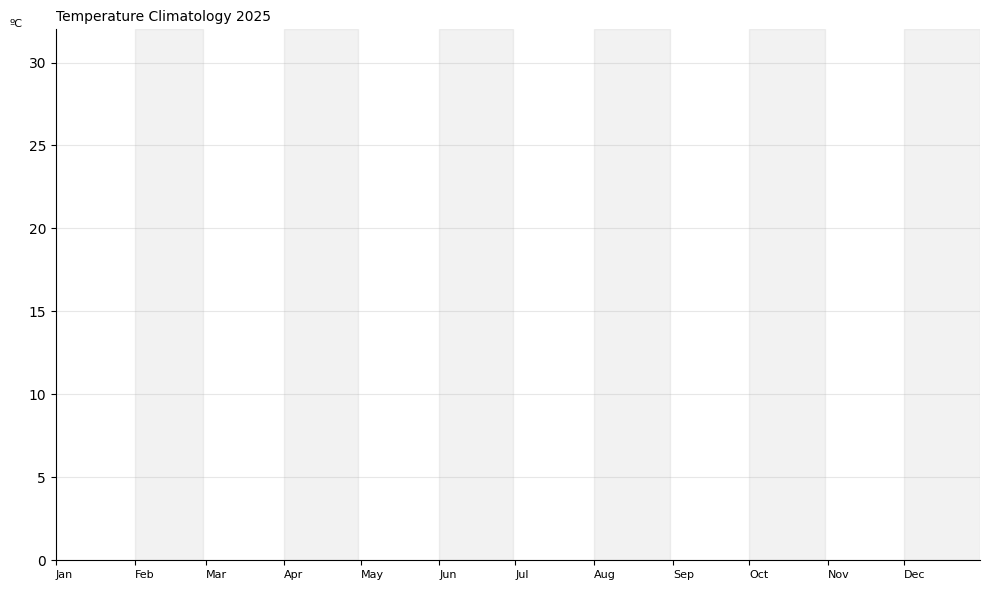

In [148]:
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Replicating geom_rect: Alternating grey background for every 2nd month
# Starting from Feb 2025
for month in range(2, 13, 2):
    start = pd.Timestamp(f'2025-{month:02d}-01')
    end = start + pd.offsets.MonthEnd(0)
    ax.axvspan(start, end, color='grey', alpha=0.1, zorder=0)

# 2. Replicating scale_y_continuous
ax.set_ylim(3, 32)
ax.set_yticks(range(0, 31, 5))
ax.set_ylabel("ºC", rotation=0, loc='top', fontsize=8)

# 3. Replicating scale_x_date
ax.set_xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# 4. Replicating theme adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='-', alpha=0.3)

# Adjust tick alignment to match 'hjust = -1.2' logic (centering under the month block)
for tick in ax.get_xticklabels():
    tick.set_horizontalalignment('left')
    tick.set_fontsize(8)

plt.title("Temperature Climatology 2025", loc='left', fontsize=10)
plt.tight_layout()
plt.show()

#### add the data

In [149]:
comp = final.copy()
comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   date         366 non-null    datetime64[ns, UTC]
 1   month        366 non-null    object             
 2   yd           366 non-null    int32              
 3   p50          366 non-null    float64            
 4   p5           366 non-null    float64            
 5   p95          366 non-null    float64            
 6   2025_median  366 non-null    float32            
 7   anom         366 non-null    float64            
dtypes: datetime64[ns, UTC](1), float32(1), float64(4), int32(1), object(1)
memory usage: 20.1+ KB


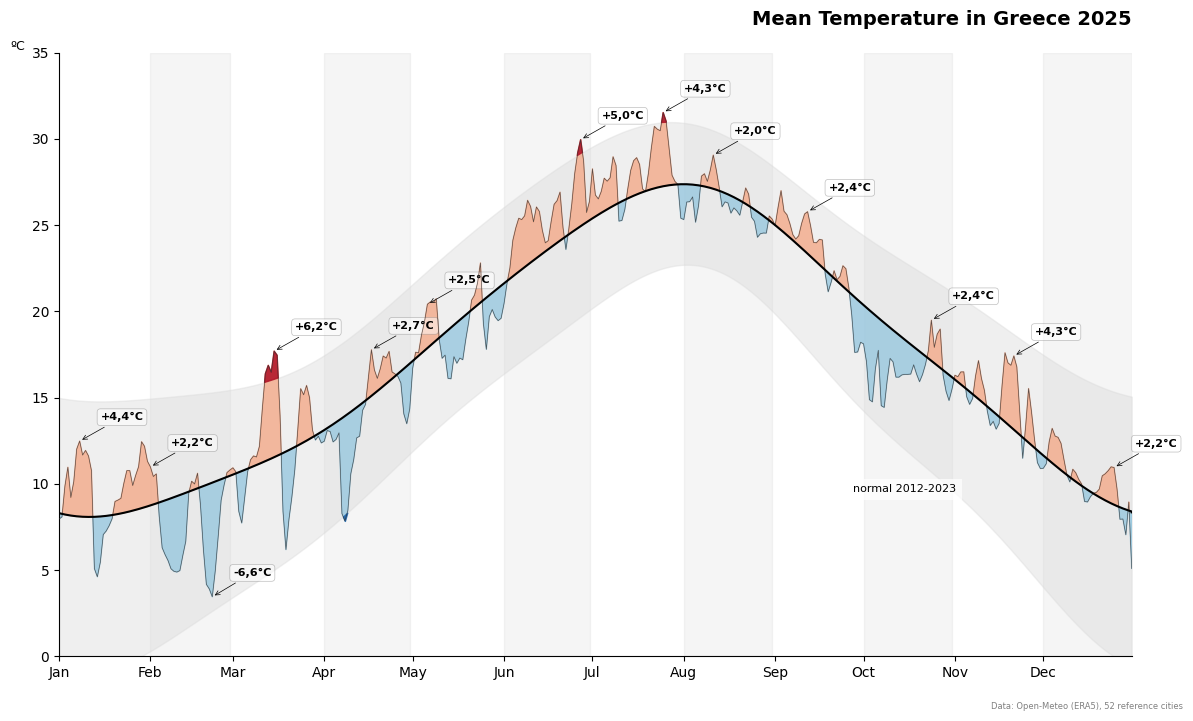

In [150]:
# Prepare figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# 1. Background Shading (Alternating Months)
for month in range(2, 13, 2):
    start = pd.Timestamp(f'2025-{month:02d}-01')
    end = start + pd.offsets.MonthEnd(0)
    ax.axvspan(start, end, color='grey', alpha=0.08, zorder=0)

# 2. Historical Range (P5-P95 Ribbon)
ax.fill_between(comp['date'], comp['p5'], comp['p95'], color='#d9d9d9', alpha=0.4, label='Typical Range (P5-P95)', zorder=1)

# # 3. Anomaly Shading (stat_difference logic)
ax.fill_between(comp['date'], comp['p50'], comp['2025_median'],
                where=(comp['2025_median'] >= comp['p50']),
                color='#f4a582', alpha=0.75, interpolate=True, zorder=2)
ax.fill_between(comp['date'], comp['p50'], comp['2025_median'],
                where=(comp['2025_median'] < comp['p50']),
                color='#92c5de', alpha=0.75, interpolate=True, zorder=2)

# 4. Extreme Highlights
ax.fill_between(comp['date'], comp['p95'], comp['2025_median'],
                where=(comp['2025_median'] > comp['p95']),
                color='#b2182b', alpha=0.90, interpolate=True, zorder=3)
ax.fill_between(comp['date'], comp['p5'], comp['2025_median'],
                where=(comp['2025_median'] < comp['p5']),
                color='#2166ac', alpha=0.90, interpolate=True, zorder=3)

# 5. Lines
## plot all the original data
ax.plot(comp['date'], comp['2025_median'], color='#333333', linewidth=0.5, alpha=0.8, zorder=4)
## plot the smooothed data
ax.plot(comp['date'], comp['p50'], color='black', linewidth=1.5, zorder=6, label='Normal (2012-2023)')

# 6. Annotations
for _, row in anot.iterrows():
    ax.annotate(f"{row['anom']:+.1f}°C".replace('.', ','),
                xy=(row['date'], row['2025_median']),
                xytext=(15, 15), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5, ec='grey', lw=0.5),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='black', lw=0.5),
                fontsize=8, fontweight='bold')

# 7. Labels and Text
ax.text(pd.Timestamp("2025-10-15"), 9.5, "normal 2012-2023",
        fontsize=8, ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Formatting
ax.set_ylim(0, 35)
ax.set_ylabel("ºC", rotation=0, loc='top', fontsize=9, labelpad=5)
ax.set_xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Title and Caption
plt.title("Mean Temperature in Greece 2025", loc='right', fontsize=14, fontweight='bold', pad=20)
fig.text(0.99, -0.02, "Data: Open-Meteo (ERA5), 52 reference cities", ha='right', fontsize=6, color='grey')

plt.tight_layout()
plt.show()

In [152]:
pd.DataFrame(data = np.array([[comp.anom.mean(), np.sum(comp['2025_median'] > comp.p95), np.sum(comp['2025_median'] < comp.p5)]]), columns=["mean_anom", 'days above_p95', 'days below_p5'])

,mean_anom,days above_p95,days below_p5
0,0.151999,9.0,1.0
